# CONVOLUTIONAL AUTOENCODER FOR ANOMALY DETECTION
# Part 1: Setup and Data Loading


In [ ]:
# ============================================================================
# Cell 1: Install and Import Required Libraries
# ============================================================================
"""
This cell installs necessary packages and imports all required libraries
for building, training, and evaluating the Convolutional Autoencoder
"""



import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version and GPU availability
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================================
# Cell 2: Load Fashion-MNIST Dataset
# ============================================================================
"""
Load the Fashion-MNIST dataset from Keras
We will use one class (T-shirt/top, class 0) as normal data
and other classes as anomalies for testing
"""

# Load Fashion-MNIST dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = fashion_mnist.load_data()

# Fashion-MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Dataset loaded successfully!")
print(f"Training data shape: {x_train_full.shape}")
print(f"Training labels shape: {y_train_full.shape}")
print(f"Test data shape: {x_test_full.shape}")
print(f"Test labels shape: {y_test_full.shape}")
print(f"\nClass names: {class_names}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset loaded successfully!
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


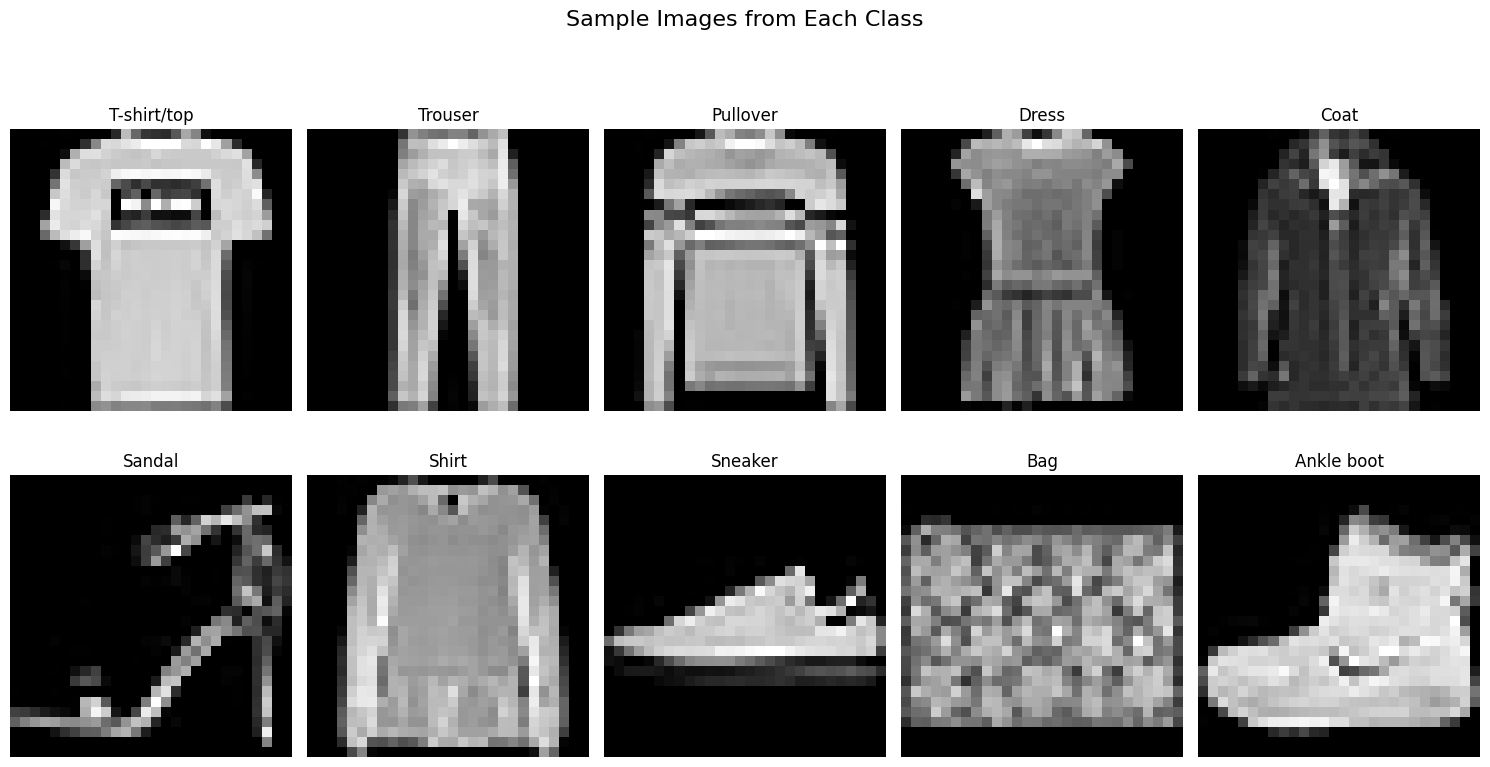

In [ ]:
# ============================================================================
# Cell 3: Visualize Sample Images from Each Class
# ============================================================================
"""
Visualize sample images from each class in the dataset
to understand the data distribution and characteristics
"""

plt.figure(figsize=(15, 8))
for i in range(10):
    # Get first image of each class
    idx = np.where(y_train_full == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[idx], cmap='gray')
    plt.title(f'{class_names[i]}')
    plt.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# Cell 4: Prepare Normal and Anomaly Data
# ============================================================================
"""
Select T-shirt/top (class 0) as the NORMAL class for training
All other classes will be considered as ANOMALIES during testing
"""

# Define normal class (T-shirt/top = 0)
NORMAL_CLASS = 0

# Extract normal data for training (only class 0)
x_train_normal = x_train_full[y_train_full == NORMAL_CLASS]
y_train_normal = y_train_full[y_train_full == NORMAL_CLASS]

# Split normal data into train and validation sets
x_train, x_val = train_test_split(x_train_normal, test_size=0.2, random_state=42)

# Prepare test set with both normal and anomalies
x_test_normal = x_test_full[y_test_full == NORMAL_CLASS]
x_test_anomaly = x_test_full[y_test_full != NORMAL_CLASS]

# Create labels for test set (0 = normal, 1 = anomaly)
y_test_normal = np.zeros(len(x_test_normal))
y_test_anomaly = np.ones(len(x_test_anomaly))

# Combine normal and anomaly test data
x_test = np.concatenate([x_test_normal, x_test_anomaly])
y_test = np.concatenate([y_test_normal, y_test_anomaly])

print(f"Training set (normal only): {x_train.shape}")
print(f"Validation set (normal only): {x_val.shape}")
print(f"Test set (normal + anomalies): {x_test.shape}")
print(f"  - Normal samples: {len(x_test_normal)}")
print(f"  - Anomaly samples: {len(x_test_anomaly)}")

Training set (normal only): (4800, 28, 28)
Validation set (normal only): (1200, 28, 28)
Test set (normal + anomalies): (10000, 28, 28)
  - Normal samples: 1000
  - Anomaly samples: 9000


In [ ]:
# ============================================================================
# Cell 5: Data Preprocessing and Normalization
# ============================================================================
"""
Preprocess the data by:
1. Normalizing pixel values to [0, 1] range
2. Reshaping images to include channel dimension
3. Converting to float32 for efficient computation
"""

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to add channel dimension (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_val = np.expand_dims(x_val, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Data preprocessing completed!")
print(f"Training data shape: {x_train.shape}")
print(f"Validation data shape: {x_val.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Data type: {x_train.dtype}")
print(f"Value range: [{x_train.min():.2f}, {x_train.max():.2f}]")

Data preprocessing completed!
Training data shape: (4800, 28, 28, 1)
Validation data shape: (1200, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Data type: float32
Value range: [0.00, 1.00]


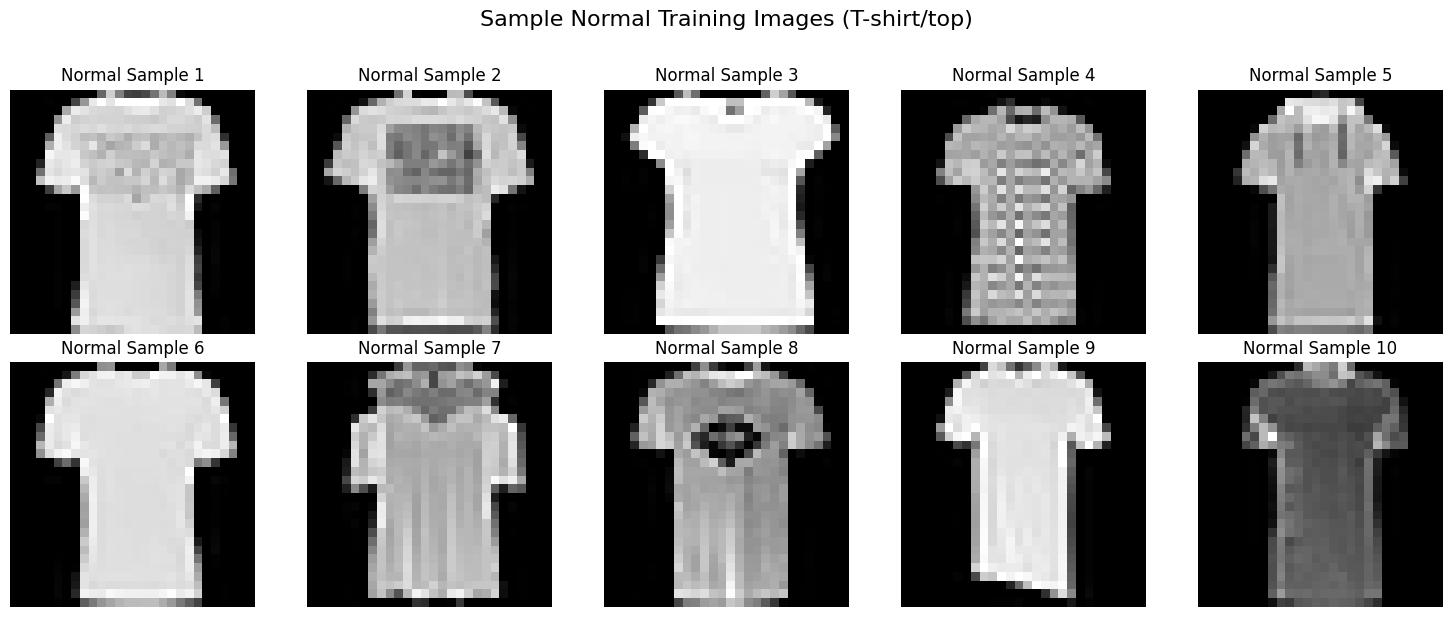

In [ ]:
# ============================================================================
# Cell 6: Visualize Normal Training Samples
# ============================================================================
"""
Display sample images from the normal training set
to verify data preprocessing and normalization
"""

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(f'Normal Sample {i+1}')
    plt.axis('off')
plt.suptitle(f'Sample Normal Training Images ({class_names[NORMAL_CLASS]})',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# CONVOLUTIONAL AUTOENCODER FOR ANOMALY DETECTION
# Part 2: Baseline Model Architecture

In [ ]:
# ============================================================================
# Cell 7: Define Baseline Convolutional Autoencoder
# ============================================================================
"""
Build a baseline Convolutional Autoencoder (CAE) with:
- Encoder: Compresses input images into latent representation
- Decoder: Reconstructs images from latent representation

Architecture:
Encoder: Conv2D -> MaxPool -> Conv2D -> MaxPool
Decoder: Conv2DTranspose -> Conv2DTranspose
"""

def build_baseline_cae(input_shape=(28, 28, 1)):
    """
    Build baseline Convolutional Autoencoder

    Args:
        input_shape: Shape of input images (height, width, channels)

    Returns:
        model: Compiled Keras model
    """

    # ========== ENCODER ==========
    encoder_input = layers.Input(shape=input_shape, name='encoder_input')

    # First convolutional block
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      name='encoder_conv1')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same', name='encoder_pool1')(x)

    # Second convolutional block
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      name='encoder_conv2')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same', name='encoder_pool2')(x)

    # ========== DECODER ==========
    # First deconvolutional block
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu',
                               padding='same', name='decoder_conv1')(encoded)

    # Second deconvolutional block
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu',
                               padding='same', name='decoder_conv2')(x)

    # Output layer - reconstruct original image
    decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid',
                                   padding='same', name='decoder_output')(x)

    # Create model
    autoencoder = models.Model(encoder_input, decoder_output, name='Baseline_CAE')

    return autoencoder


# Build the baseline model
baseline_model = build_baseline_cae(input_shape=(28, 28, 1))

# Display model architecture
baseline_model.summary()

Model: "Baseline_CAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv1 (Conv2D)          │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool1 (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv2 (Conv2D)          │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool2 (MaxPooling2D)    │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv1 (Conv2DTranspose) │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv2 (Conv2DTranspose) │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================================
# Cell 8: Compile Baseline Model
# ============================================================================
"""
Compile the model with:
- Optimizer: Adam with default learning rate
- Loss function: Mean Squared Error (MSE) for reconstruction
- Metrics: MSE and MAE for monitoring
"""

# Compile the model
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',  # Mean Squared Error for reconstruction
    metrics=['mse', 'mae']
)

print("Baseline model compiled successfully!")

Baseline model compiled successfully!


In [ ]:
# ============================================================================
# Cell 9: Setup Training Callbacks
# ============================================================================
"""
Setup callbacks for training:
1. EarlyStopping: Stop training if validation loss doesn't improve
2. ModelCheckpoint: Save best model based on validation loss
3. ReduceLROnPlateau: Reduce learning rate when training plateaus
"""

# Define callbacks
callbacks_baseline = [
    # Stop training if validation loss doesn't improve for 10 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # Save the best model
    ModelCheckpoint(
        'baseline_cae_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate if validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Training callbacks configured!")

Training callbacks configured!


In [ ]:
# ============================================================================
# Cell 10: Train Baseline Model
# ============================================================================
"""
Train the baseline autoencoder on NORMAL data only
The model learns to reconstruct normal images with minimal error
"""

# Training parameters
EPOCHS = 50
BATCH_SIZE = 128

# Train the model
print("Starting training of baseline model...")
print(f"Training on {len(x_train)} samples")
print(f"Validating on {len(x_val)} samples")

baseline_history = baseline_model.fit(
    x_train, x_train,  # Input and target are the same (reconstruction)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, x_val),
    callbacks=callbacks_baseline,
    verbose=1
)

print("\nBaseline model training completed!")

Starting training of baseline model...
Training on 4800 samples
Validating on 1200 samples
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1272 - mae: 0.3153 - mse: 0.1272
Epoch 1: val_loss improved from inf to 0.02544, saving model to baseline_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - loss: 0.1262 - mae: 0.3135 - mse: 0.1262 - val_loss: 0.0254 - val_mae: 0.1085 - val_mse: 0.0254 - learning_rate: 0.0010
Epoch 2/50
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0239 - mae: 0.1036 - mse: 0.0239
Epoch 2: val_loss improved from 0.02544 to 0.01644, saving model to baseline_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0236 - mae: 0.1030 - mse: 0.0236 - val_loss: 0.0164 - val_mae: 0.0816 - val_mse: 0.0164 - learning_rate: 0.0010
Epoch 3/50
34/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0156 - mae: 0.0787 - mse: 0.0156
Epoch 3: val_loss improved from 0.01644 to 0.01361, saving model to baseline_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0155 - mae: 0.0782 - mse: 0.0155 - val_loss: 0.0136 - val_mae: 0.0703 - val_mse: 0.0136 - learning_rate: 0.0010
Epoch 4/50
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0132 - mae: 0.0690 - mse: 0.0132
Epoch 4: val_loss improved from 0.01361 to 0.01204, saving model to baseline_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0131 - mae: 0.0688 - mse: 0.0131 - val_loss: 0.0120 - val_mae: 0.0646 - val_mse: 0.0120 - learning_rate: 0.0010
Epoch 5/50
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0117 - mae: 0.0636 - mse: 0.0117
Epoch 5: val_loss improved from 0.01204 to 0.01108, saving model to baseline_cae_best.h5


...

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0045 - mae: 0.0346 - mse: 0.0045 - val_loss: 0.0045 - val_mae: 0.0344 - val_mse: 0.0045 - learning_rate: 0.0010
Epoch 47/50
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0045 - mae: 0.0345 - mse: 0.0045
Epoch 47: val_loss improved from 0.00453 to 0.00447, saving model to baseline_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0045 - mae: 0.0344 - mse: 0.0045 - val_loss: 0.0045 - val_mae: 0.0342 - val_mse: 0.0045 - learning_rate: 0.0010
Epoch 48/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0044 - mae: 0.0343 - mse: 0.0044
Epoch 48: val_loss improved from 0.00447 to 0.00442, saving model to baseline_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0044 - mae: 0.0343 - mse: 0.0044 - val_loss: 0.0044 - val_mae: 0.0340 - val_mse: 0.0044 - learning_rate: 0.0010
Epoch 49/50
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0044 - mae: 0.0341 - mse: 0.0044 
Epoch 49: val_loss improved from 0.00442 to 0.00436, saving model to baseline_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0044 - mae: 0.0340 - mse: 0.0044 - val_loss: 0.0044 - val_mae: 0.0338 - val_mse: 0.0044 - learning_rate: 0.0010
Epoch 50/50
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0043 - mae: 0.0338 - mse: 0.0043
Epoch 50: val_loss improved from 0.00436 to 0.00431, saving model to baseline_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0043 - mae: 0.0338 - mse: 0.0043 - val_loss: 0.0043 - val_mae: 0.0336 - val_mse: 0.0043 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 50.

Baseline model training completed!


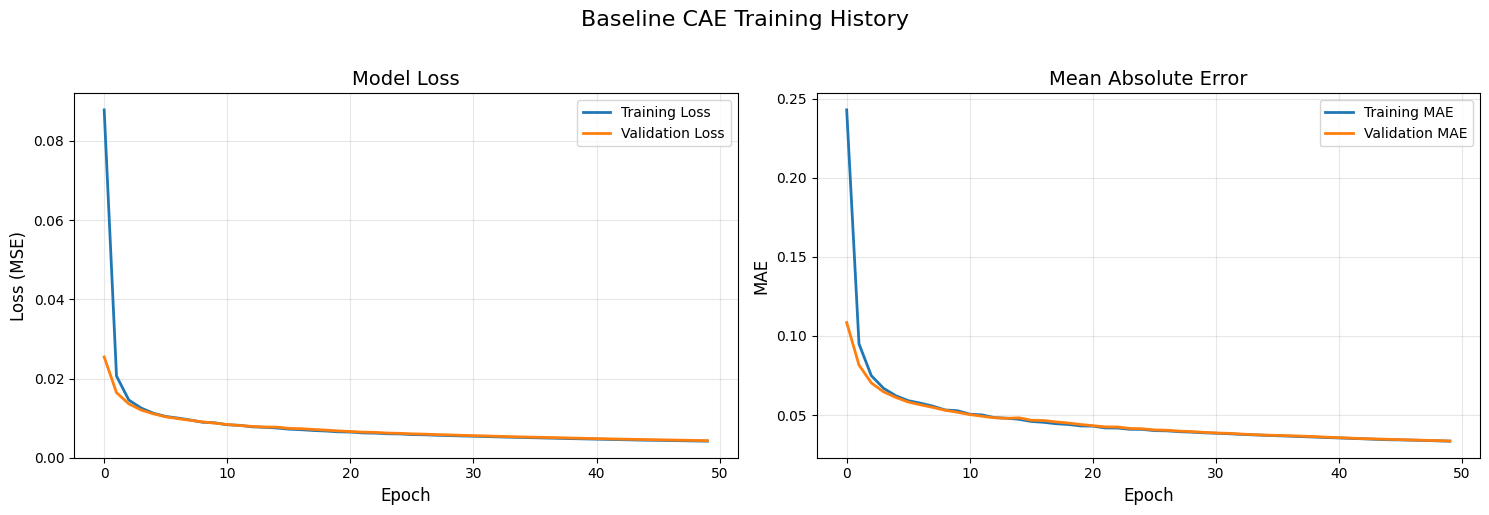


Final Training Loss: 0.004178
Final Validation Loss: 0.004311


In [ ]:
# ============================================================================
# Cell 11: Visualize Training History
# ============================================================================
"""
Plot training and validation loss curves
to assess model convergence and overfitting
"""

def plot_training_history(history, title='Training History'):
    """
    Plot training and validation loss curves

    Args:
        history: Keras training history object
        title: Plot title
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('Model Loss', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot MAE
    axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('Mean Absolute Error', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Plot baseline training history
plot_training_history(baseline_history, 'Baseline CAE Training History')

# Print final metrics
final_train_loss = baseline_history.history['loss'][-1]
final_val_loss = baseline_history.history['val_loss'][-1]
print(f"\nFinal Training Loss: {final_train_loss:.6f}")
print(f"Final Validation Loss: {final_val_loss:.6f}")


# CONVOLUTIONAL AUTOENCODER FOR ANOMALY DETECTION
# Part 3: Improved Model Architecture

In [ ]:
# ============================================================================
# Cell 12: Define Improved Convolutional Autoencoder
# ============================================================================
"""
Build an improved CAE with enhancements:
1. Additional convolutional layers (deeper network)
2. Batch Normalization for stable training
3. Dropout for regularization
4. Skip connections for better reconstruction
5. LeakyReLU activation for better gradient flow

Architecture improvements over baseline:
- Deeper encoder/decoder (3 conv blocks instead of 2)
- Batch normalization after each conv layer
- Dropout layers for regularization
- Skip connections from encoder to decoder
"""

def build_improved_cae(input_shape=(28, 28, 1)):
    """
    Build improved Convolutional Autoencoder with enhancements

    Args:
        input_shape: Shape of input images (height, width, channels)

    Returns:
        model: Compiled Keras model
    """

    # ========== ENCODER ==========
    encoder_input = layers.Input(shape=input_shape, name='encoder_input')

    # First encoder block
    x = layers.Conv2D(32, (3, 3), padding='same', name='encoder_conv1')(encoder_input)
    x = layers.BatchNormalization(name='encoder_bn1')(x)
    x = layers.LeakyReLU(alpha=0.2, name='encoder_activation1')(x)
    skip1 = x  # Save for skip connection
    x = layers.MaxPooling2D((2, 2), padding='same', name='encoder_pool1')(x)
    x = layers.Dropout(0.25, name='encoder_dropout1')(x)

    # Second encoder block
    x = layers.Conv2D(64, (3, 3), padding='same', name='encoder_conv2')(x)
    x = layers.BatchNormalization(name='encoder_bn2')(x)
    x = layers.LeakyReLU(alpha=0.2, name='encoder_activation2')(x)
    skip2 = x  # Save for skip connection
    x = layers.MaxPooling2D((2, 2), padding='same', name='encoder_pool2')(x)
    x = layers.Dropout(0.25, name='encoder_dropout2')(x)

    # Third encoder block (bottleneck)
    x = layers.Conv2D(128, (3, 3), padding='same', name='encoder_conv3')(x)
    x = layers.BatchNormalization(name='encoder_bn3')(x)
    encoded = layers.LeakyReLU(alpha=0.2, name='encoder_activation3')(x)

    # ========== DECODER ==========
    # First decoder block
    x = layers.Conv2DTranspose(128, (3, 3), strides=1, padding='same',
                               name='decoder_conv1')(encoded)
    x = layers.BatchNormalization(name='decoder_bn1')(x)
    x = layers.LeakyReLU(alpha=0.2, name='decoder_activation1')(x)
    x = layers.Dropout(0.25, name='decoder_dropout1')(x)

    # Second decoder block with skip connection
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same',
                               name='decoder_conv2')(x)
    x = layers.BatchNormalization(name='decoder_bn2')(x)
    x = layers.LeakyReLU(alpha=0.2, name='decoder_activation2')(x)
    x = layers.Concatenate(name='skip_connection2')([x, skip2])  # Skip connection
    x = layers.Dropout(0.25, name='decoder_dropout2')(x)

    # Third decoder block with skip connection
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same',
                               name='decoder_conv3')(x)
    x = layers.BatchNormalization(name='decoder_bn3')(x)
    x = layers.LeakyReLU(alpha=0.2, name='decoder_activation3')(x)
    x = layers.Concatenate(name='skip_connection1')([x, skip1])  # Skip connection

    # Output layer - reconstruct original image
    decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid',
                                   padding='same', name='decoder_output')(x)

    # Create model
    autoencoder = models.Model(encoder_input, decoder_output, name='Improved_CAE')

    return autoencoder


# Build the improved model
improved_model = build_improved_cae(input_shape=(28, 28, 1))

# Display model architecture
improved_model.summary()

Model: "Improved_CAE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_conv1       │ (None, 28, 28,    │        320 │ encoder_input[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_bn1         │ (None, 28, 28,    │        128 │ encoder_conv1[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_activation1 │ (None, 28, 28,    │          0 │ encoder_bn1[0][0] │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_pool1       │ (None, 14, 14,    │          0 │ encoder_activati… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout1    │ (None, 14, 14,    │          0 │ encoder_pool1[0]… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_conv2       │ (None, 14, 14,    │     18,496 │ encoder_dropout1… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_bn2         │ (None, 14, 14,    │        256 │ encoder_conv2[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_activation2 │ (None, 14, 14,    │          0 │ encoder_bn2[0][0] │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_pool2       │ (None, 7, 7, 64)  │          0 │ encoder_activati… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout2    │ (None, 7, 7, 64)  │          0 │ encoder_pool2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_conv3       │ (None, 7, 7, 128) │     73,856 │ encoder_dropout2… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_bn3         │ (None, 7, 7, 128) │        512 │ encoder_conv3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_activation3 │ (None, 7, 7, 128) │          0 │ encoder_bn3[0][0] │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_conv1       │ (None, 7, 7, 128) │    147,584 │ encoder_activati… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_bn1         │ (None, 7, 7, 128) │        512 │ decoder_conv1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_activation1 │ (None, 7, 7, 128) │          0 │ decoder_bn1[0][0

 Total params: 353,313 (1.35 MB)

 Trainable params: 352,417 (1.34 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# ============================================================================
# Cell 13: Compile Improved Model
# ============================================================================
"""
Compile the improved model with same configuration as baseline
for fair comparison
"""

# Compile the model
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',  # Mean Squared Error for reconstruction
    metrics=['mse', 'mae']
)

print("Improved model compiled successfully!")

Improved model compiled successfully!


In [ ]:
# ============================================================================
# Cell 14: Train Improved Model
# ============================================================================
"""
Train the improved autoencoder on NORMAL data only
with the same training configuration as baseline
"""

# Setup callbacks for improved model
callbacks_improved = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'improved_cae_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train the model
print("Starting training of improved model...")
print(f"Training on {len(x_train)} samples")
print(f"Validating on {len(x_val)} samples")

improved_history = improved_model.fit(
    x_train, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, x_val),
    callbacks=callbacks_improved,
    verbose=1
)

print("\nImproved model training completed!")

Starting training of improved model...
Training on 4800 samples
Validating on 1200 samples
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.0414 - mae: 0.1411 - mse: 0.0414
Epoch 1: val_loss improved from inf to 0.11019, saving model to improved_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - loss: 0.0409 - mae: 0.1398 - mse: 0.0409 - val_loss: 0.1102 - val_mae: 0.3054 - val_mse: 0.1102 - learning_rate: 0.0010
Epoch 2/50
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0042 - mae: 0.0458 - mse: 0.0042
Epoch 2: val_loss improved from 0.11019 to 0.08885, saving model to improved_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0041 - mae: 0.0454 - mse: 0.0041 - val_loss: 0.0889 - val_mae: 0.2767 - val_mse: 0.0889 - learning_rate: 0.0010
Epoch 3/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0022 - mae: 0.0347 - mse: 0.0022
Epoch 3: val_loss improved from 0.08885 to 0.07570, saving model to improved_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0021 - mae: 0.0346 - mse: 0.0021 - val_loss: 0.0757 - val_mae: 0.2540 - val_mse: 0.0757 - learning_rate: 0.0010
Epoch 4/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0017 - mae: 0.0304 - mse: 0.0017
Epoch 4: val_loss improved from 0.07570 to 0.06737, saving model to improved_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0017 - mae: 0.0304 - mse: 0.0017 - val_loss: 0.0674 - val_mae: 0.2367 - val_mse: 0.0674 - learning_rate: 0.0010
Epoch 5/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0014 - mae: 0.0281 - mse: 0.0014
Epoch 5: val_loss improved from 0.06737 to 0.05973, saving model to improved_cae_best.h5


...

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.6443e-04 - mae: 0.0166 - mse: 5.6443e-04 - val_loss: 5.1753e-04 - val_mae: 0.0155 - val_mse: 5.1753e-04 - learning_rate: 5.0000e-04
Epoch 32/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.6252e-04 - mae: 0.0166 - mse: 5.6252e-04
Epoch 32: val_loss improved from 0.00052 to 0.00051, saving model to improved_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.6197e-04 - mae: 0.0166 - mse: 5.6197e-04 - val_loss: 5.1173e-04 - val_mae: 0.0155 - val_mse: 5.1173e-04 - learning_rate: 5.0000e-04
Epoch 33/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.5916e-04 - mae: 0.0165 - mse: 5.5916e-04
Epoch 33: val_loss improved from 0.00051 to 0.00050, saving model to improved_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.5861e-04 - mae: 0.0165 - mse: 5.5861e-04 - val_loss: 5.0239e-04 - val_mae: 0.0153 - val_mse: 5.0239e-04 - learning_rate: 5.0000e-04
Epoch 34/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.5453e-04 - mae: 0.0164 - mse: 5.5453e-04
Epoch 34: val_loss improved from 0.00050 to 0.00049, saving model to improved_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.5407e-04 - mae: 0.0164 - mse: 5.5407e-04 - val_loss: 4.9401e-04 - val_mae: 0.0152 - val_mse: 4.9401e-04 - learning_rate: 5.0000e-04
Epoch 35/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.4977e-04 - mae: 0.0163 - mse: 5.4977e-04
Epoch 35: val_loss improved from 0.00049 to 0.00049, saving model to improved_cae_best.h5



Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.4932e-04 - mae: 0.0163 - mse: 5.4932e-04 - val_loss: 4.8625e-04 - val_mae: 0.0151 - val_mse: 4.8625e-04 - learning_rate: 5.0000e-04
Epoch 36/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.1736e-04 - mae: 0.0158 - mse: 5.1736e-04
Epoch 36: val_loss did not improve from 0.00049
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.1686e-04 - mae: 0.0157 - mse: 5.1686e-04 - val_loss: 5.3189e-04 - val_mae: 0.0159 - val_mse: 5.3189e-04 - learning_rate: 2.5000e-04
Epoch 37/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.1627e-04 - mae: 0.0158 - mse: 5.1627e-04
Epoch 37: val_loss did not improve from 0.00049
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.1556e-04 - mae: 0.0158 - mse: 5.1556e-04 - val_loss: 5.2645e-04 - val_mae: 0.0158 - val_mse: 5.2645e-04 - learning_rate: 2.5000e-04
Epoch 38/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.1453e-04 - m

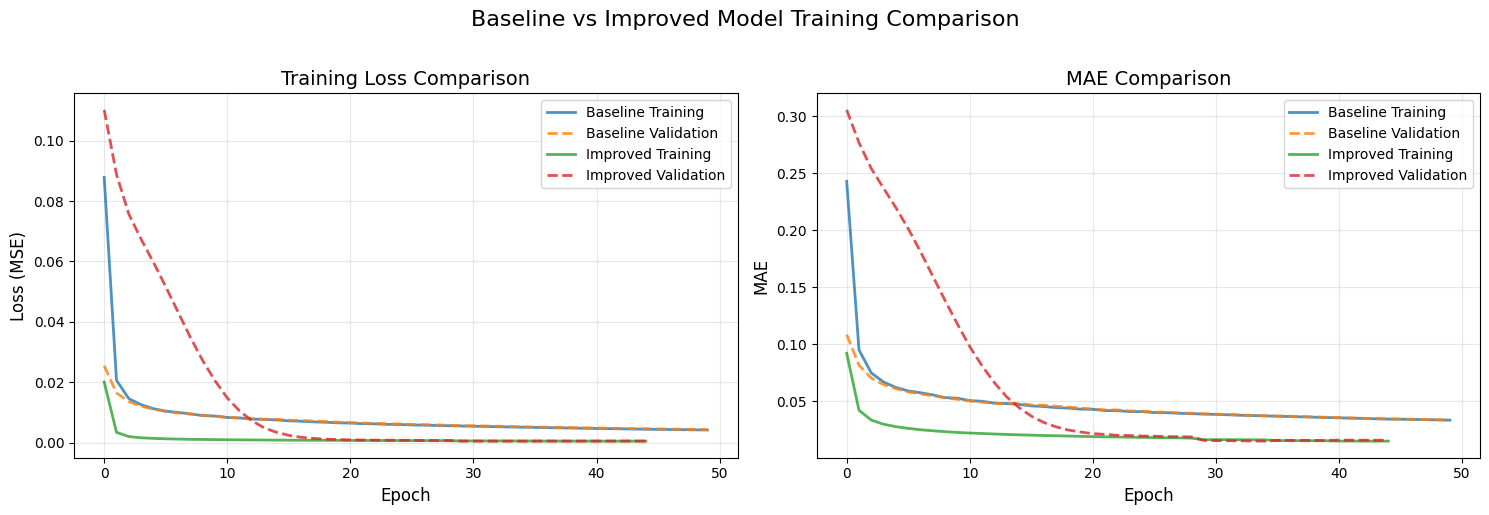


TRAINING METRICS COMPARISON
Baseline  - Final Train Loss: 0.004178
Baseline  - Final Val Loss:   0.004311
Improved  - Final Train Loss: 0.000482
Improved  - Final Val Loss:   0.000524


In [ ]:
# ============================================================================
# Cell 15: Compare Training Histories
# ============================================================================
"""
Compare baseline and improved model training curves
to evaluate the impact of architectural improvements
"""

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot training loss comparison
axes[0].plot(baseline_history.history['loss'], label='Baseline Training',
             linewidth=2, alpha=0.8)
axes[0].plot(baseline_history.history['val_loss'], label='Baseline Validation',
             linewidth=2, alpha=0.8, linestyle='--')
axes[0].plot(improved_history.history['loss'], label='Improved Training',
             linewidth=2, alpha=0.8)
axes[0].plot(improved_history.history['val_loss'], label='Improved Validation',
             linewidth=2, alpha=0.8, linestyle='--')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training Loss Comparison', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot MAE comparison
axes[1].plot(baseline_history.history['mae'], label='Baseline Training',
             linewidth=2, alpha=0.8)
axes[1].plot(baseline_history.history['val_mae'], label='Baseline Validation',
             linewidth=2, alpha=0.8, linestyle='--')
axes[1].plot(improved_history.history['mae'], label='Improved Training',
             linewidth=2, alpha=0.8)
axes[1].plot(improved_history.history['val_mae'], label='Improved Validation',
             linewidth=2, alpha=0.8, linestyle='--')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('MAE Comparison', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline vs Improved Model Training Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Print comparison of final metrics
print("\n" + "="*60)
print("TRAINING METRICS COMPARISON")
print("="*60)
print(f"Baseline  - Final Train Loss: {baseline_history.history['loss'][-1]:.6f}")
print(f"Baseline  - Final Val Loss:   {baseline_history.history['val_loss'][-1]:.6f}")
print(f"Improved  - Final Train Loss: {improved_history.history['loss'][-1]:.6f}")
print(f"Improved  - Final Val Loss:   {improved_history.history['val_loss'][-1]:.6f}")
print("="*60)

# CONVOLUTIONAL AUTOENCODER FOR ANOMALY DETECTION
# Part 4: Model Evaluation and Anomaly Detection

In [ ]:
# ============================================================================
# Cell 16: Compute Reconstruction Errors
# ============================================================================
"""
Compute reconstruction errors for test set
Reconstruction error = MSE between original and reconstructed image
Higher error indicates anomalous samples
"""

def compute_reconstruction_error(model, data):
    """
    Compute reconstruction error for each sample

    Args:
        model: Trained autoencoder model
        data: Input images

    Returns:
        errors: Reconstruction error for each sample
        reconstructions: Reconstructed images
    """
    # Get reconstructions
    reconstructions = model.predict(data, verbose=0)

    # Compute MSE for each sample
    errors = np.mean(np.square(data - reconstructions), axis=(1, 2, 3))

    return errors, reconstructions


# Compute errors for baseline model
print("Computing reconstruction errors for baseline model...")
baseline_errors, baseline_reconstructions = compute_reconstruction_error(
    baseline_model, x_test
)

# Compute errors for improved model
print("Computing reconstruction errors for improved model...")
improved_errors, improved_reconstructions = compute_reconstruction_error(
    improved_model, x_test
)

print("Reconstruction errors computed successfully!")
print(f"Error range (baseline): [{baseline_errors.min():.6f}, {baseline_errors.max():.6f}]")
print(f"Error range (improved): [{improved_errors.min():.6f}, {improved_errors.max():.6f}]")

Computing reconstruction errors for baseline model...
Computing reconstruction errors for improved model...
Reconstruction errors computed successfully!
Error range (baseline): [0.000696, 0.067763]
Error range (improved): [0.000160, 0.003030]


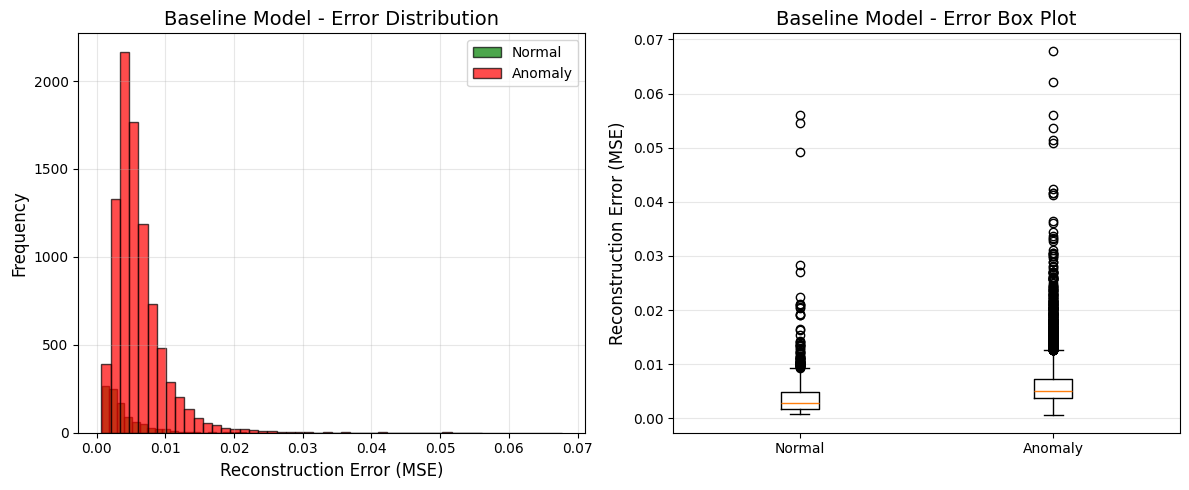


Baseline Model Error Statistics:
Normal   - Mean: 0.004025, Std: 0.004256
Anomaly  - Mean: 0.006075, Std: 0.003952
Separation: 0.002049


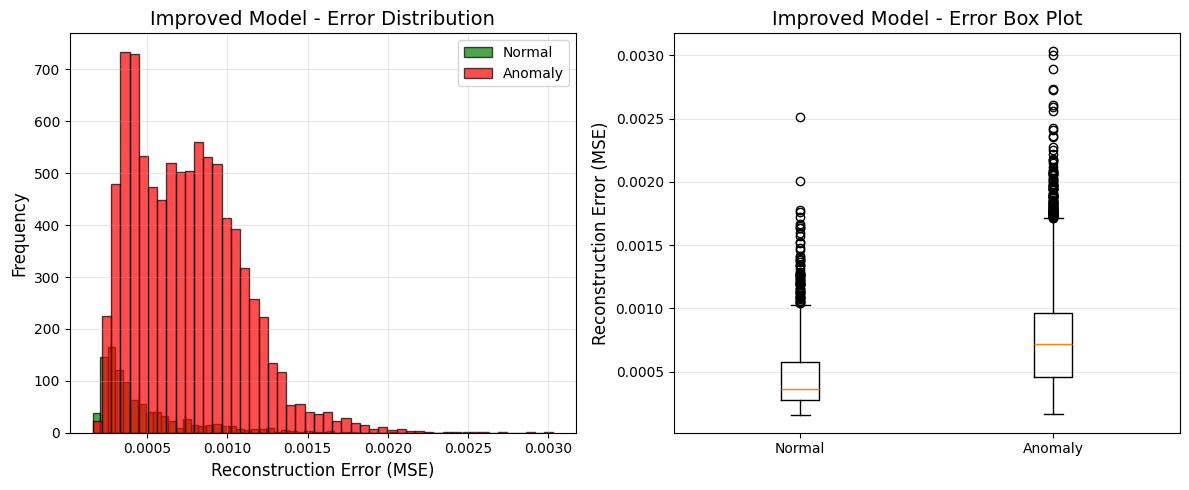


Improved Model Error Statistics:
Normal   - Mean: 0.000477, Std: 0.000305
Anomaly  - Mean: 0.000746, Std: 0.000342
Separation: 0.000270


In [ ]:
# ============================================================================
# Cell 17: Visualize Reconstruction Error Distribution
# ============================================================================
"""
Plot histogram of reconstruction errors for normal and anomalous samples
Good separation indicates effective anomaly detection
"""

def plot_error_distribution(errors, labels, model_name='Model'):
    """
    Plot reconstruction error distribution for normal vs anomalous samples

    Args:
        errors: Reconstruction errors
        labels: True labels (0=normal, 1=anomaly)
        model_name: Name of the model for title
    """
    normal_errors = errors[labels == 0]
    anomaly_errors = errors[labels == 1]

    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(normal_errors, bins=50, alpha=0.7, label='Normal', color='green', edgecolor='black')
    plt.hist(anomaly_errors, bins=50, alpha=0.7, label='Anomaly', color='red', edgecolor='black')
    plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'{model_name} - Error Distribution', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Box plot
    plt.subplot(1, 2, 2)
    data_to_plot = [normal_errors, anomaly_errors]
    plt.boxplot(data_to_plot, labels=['Normal', 'Anomaly'])
    plt.ylabel('Reconstruction Error (MSE)', fontsize=12)
    plt.title(f'{model_name} - Error Box Plot', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"\n{model_name} Error Statistics:")
    print(f"Normal   - Mean: {normal_errors.mean():.6f}, Std: {normal_errors.std():.6f}")
    print(f"Anomaly  - Mean: {anomaly_errors.mean():.6f}, Std: {anomaly_errors.std():.6f}")
    print(f"Separation: {(anomaly_errors.mean() - normal_errors.mean()):.6f}")


# Plot for baseline model
plot_error_distribution(baseline_errors, y_test, 'Baseline Model')

# Plot for improved model
plot_error_distribution(improved_errors, y_test, 'Improved Model')

In [ ]:
# ============================================================================
# Cell 18: Determine Optimal Threshold
# ============================================================================
"""
Find optimal threshold for anomaly detection using:
1. 95th percentile of normal validation errors
2. ROC curve analysis (maximize F1-score)
"""

# Compute validation errors for threshold selection
baseline_val_errors, _ = compute_reconstruction_error(baseline_model, x_val)
improved_val_errors, _ = compute_reconstruction_error(improved_model, x_val)

# Method 1: 95th percentile of validation errors
baseline_threshold_percentile = np.percentile(baseline_val_errors, 95)
improved_threshold_percentile = np.percentile(improved_val_errors, 95)

print("Threshold Selection (95th Percentile Method):")
print(f"Baseline threshold:  {baseline_threshold_percentile:.6f}")
print(f"Improved threshold:  {improved_threshold_percentile:.6f}")

# Method 2: Optimal threshold from ROC curve (maximize Youden's J statistic)
from sklearn.metrics import roc_curve

def find_optimal_threshold(y_true, errors):
    """
    Find optimal threshold using Youden's J statistic
    J = Sensitivity + Specificity - 1
    """
    fpr, tpr, thresholds = roc_curve(y_true, errors)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    return thresholds[optimal_idx]

baseline_threshold_optimal = find_optimal_threshold(y_test, baseline_errors)
improved_threshold_optimal = find_optimal_threshold(y_test, improved_errors)

print("\nThreshold Selection (Optimal ROC Method):")
print(f"Baseline threshold:  {baseline_threshold_optimal:.6f}")
print(f"Improved threshold:  {improved_threshold_optimal:.6f}")

# Use optimal thresholds for final evaluation
baseline_threshold = baseline_threshold_optimal
improved_threshold = improved_threshold_optimal

Threshold Selection (95th Percentile Method):
Baseline threshold:  0.012417
Improved threshold:  0.001143

Threshold Selection (Optimal ROC Method):
Baseline threshold:  0.003592
Improved threshold:  0.000503



Baseline Model - ANOMALY DETECTION PERFORMANCE
Threshold: 0.003592

              precision    recall  f1-score   support

      Normal     0.2373    0.6330    0.3452      1000
     Anomaly     0.9500    0.7740    0.8530      9000

    accuracy                         0.7599     10000
   macro avg     0.5936    0.7035    0.5991     10000
weighted avg     0.8787    0.7599    0.8022     10000



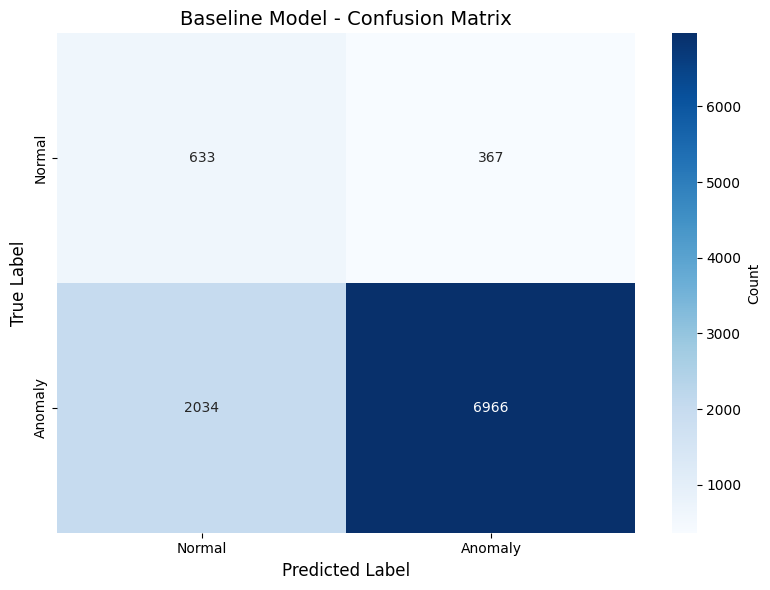


Improved Model - ANOMALY DETECTION PERFORMANCE
Threshold: 0.000503

              precision    recall  f1-score   support

      Normal     0.2063    0.7030    0.3190      1000
     Anomaly     0.9549    0.6994    0.8075      9000

    accuracy                         0.6998     10000
   macro avg     0.5806    0.7012    0.5632     10000
weighted avg     0.8801    0.6998    0.7586     10000



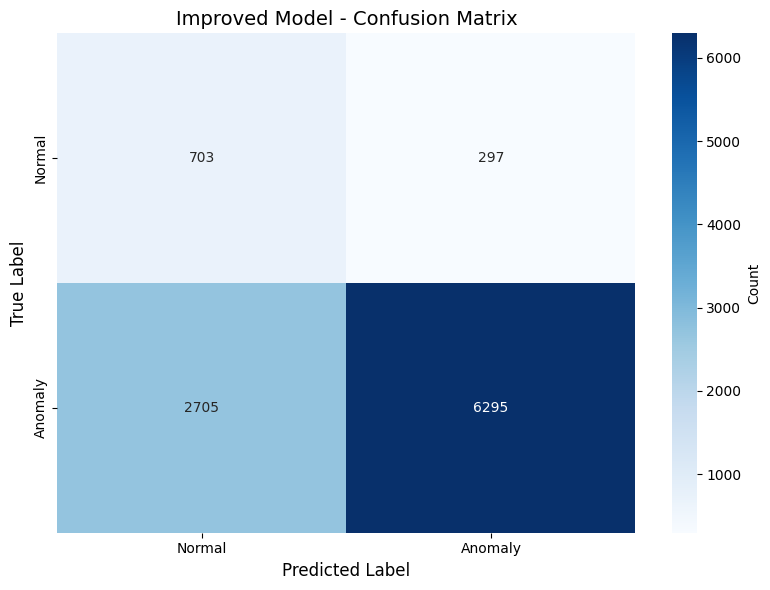

In [ ]:
# ============================================================================
# Cell 19: Anomaly Detection Performance Metrics
# ============================================================================
"""
Evaluate anomaly detection performance using:
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC score
- Confusion matrix
"""

def evaluate_anomaly_detection(errors, labels, threshold, model_name='Model'):
    """
    Evaluate anomaly detection performance

    Args:
        errors: Reconstruction errors
        labels: True labels (0=normal, 1=anomaly)
        threshold: Detection threshold
        model_name: Name of the model
    """
    # Predictions: error > threshold => anomaly (1), else normal (0)
    predictions = (errors > threshold).astype(int)

    # Classification report
    print(f"\n{'='*60}")
    print(f"{model_name} - ANOMALY DETECTION PERFORMANCE")
    print(f"{'='*60}")
    print(f"Threshold: {threshold:.6f}\n")
    print(classification_report(labels, predictions,
                                target_names=['Normal', 'Anomaly'],
                                digits=4))

    # Confusion matrix
    cm = confusion_matrix(labels, predictions)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'],
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14)
    plt.tight_layout()
    plt.show()

    return predictions


# Evaluate baseline model
baseline_predictions = evaluate_anomaly_detection(
    baseline_errors, y_test, baseline_threshold, 'Baseline Model'
)

# Evaluate improved model
improved_predictions = evaluate_anomaly_detection(
    improved_errors, y_test, improved_threshold, 'Improved Model'
)

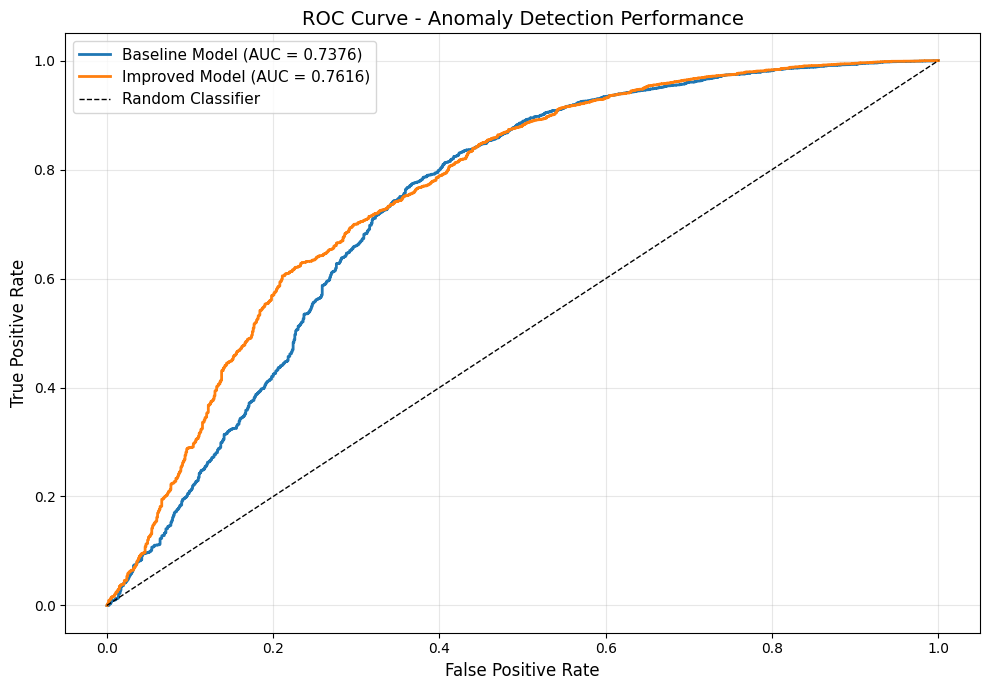


ROC-AUC Scores:
Baseline Model: 0.7376
Improved Model: 0.7616
Improvement: 0.0240


In [ ]:
# ============================================================================
# Cell 20: ROC Curve and AUC Analysis
# ============================================================================
"""
Plot ROC curves and compute AUC scores
to compare model performance
"""

from sklearn.metrics import roc_auc_score

# Compute ROC curves
baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_errors)
improved_fpr, improved_tpr, _ = roc_curve(y_test, improved_errors)

# Compute AUC scores
baseline_auc = roc_auc_score(y_test, baseline_errors)
improved_auc = roc_auc_score(y_test, improved_errors)

# Plot ROC curves
plt.figure(figsize=(10, 7))
plt.plot(baseline_fpr, baseline_tpr, linewidth=2,
         label=f'Baseline Model (AUC = {baseline_auc:.4f})')
plt.plot(improved_fpr, improved_tpr, linewidth=2,
         label=f'Improved Model (AUC = {improved_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Anomaly Detection Performance', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nROC-AUC Scores:")
print(f"Baseline Model: {baseline_auc:.4f}")
print(f"Improved Model: {improved_auc:.4f}")
print(f"Improvement: {(improved_auc - baseline_auc):.4f}")



# CONVOLUTIONAL AUTOENCODER FOR ANOMALY DETECTION
# Part 5: Reconstruction Visualization and Error Maps

Baseline Model - Normal Samples:


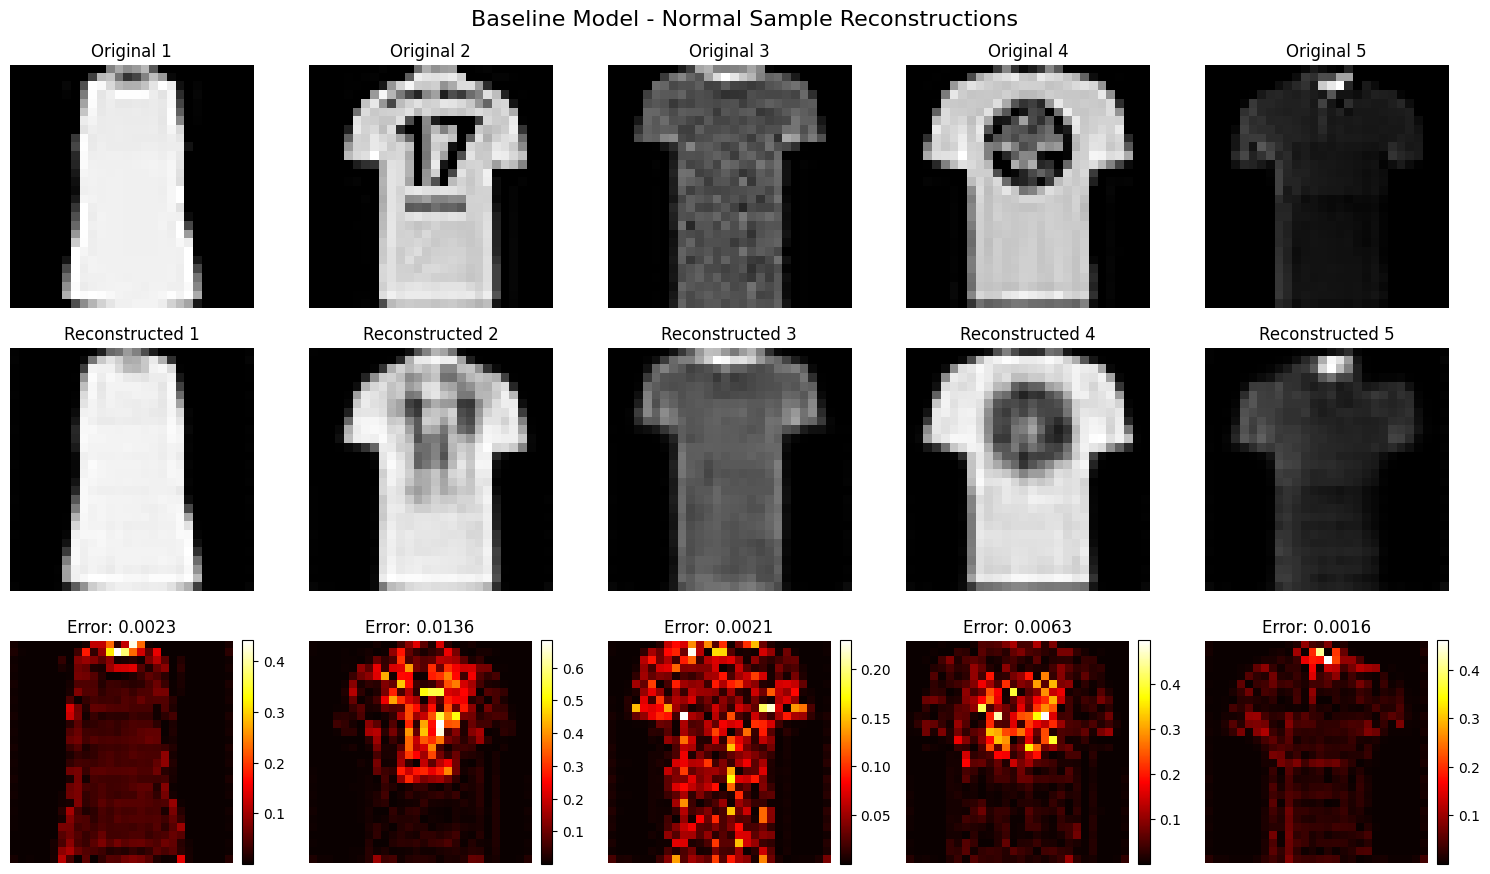


Improved Model - Normal Samples:


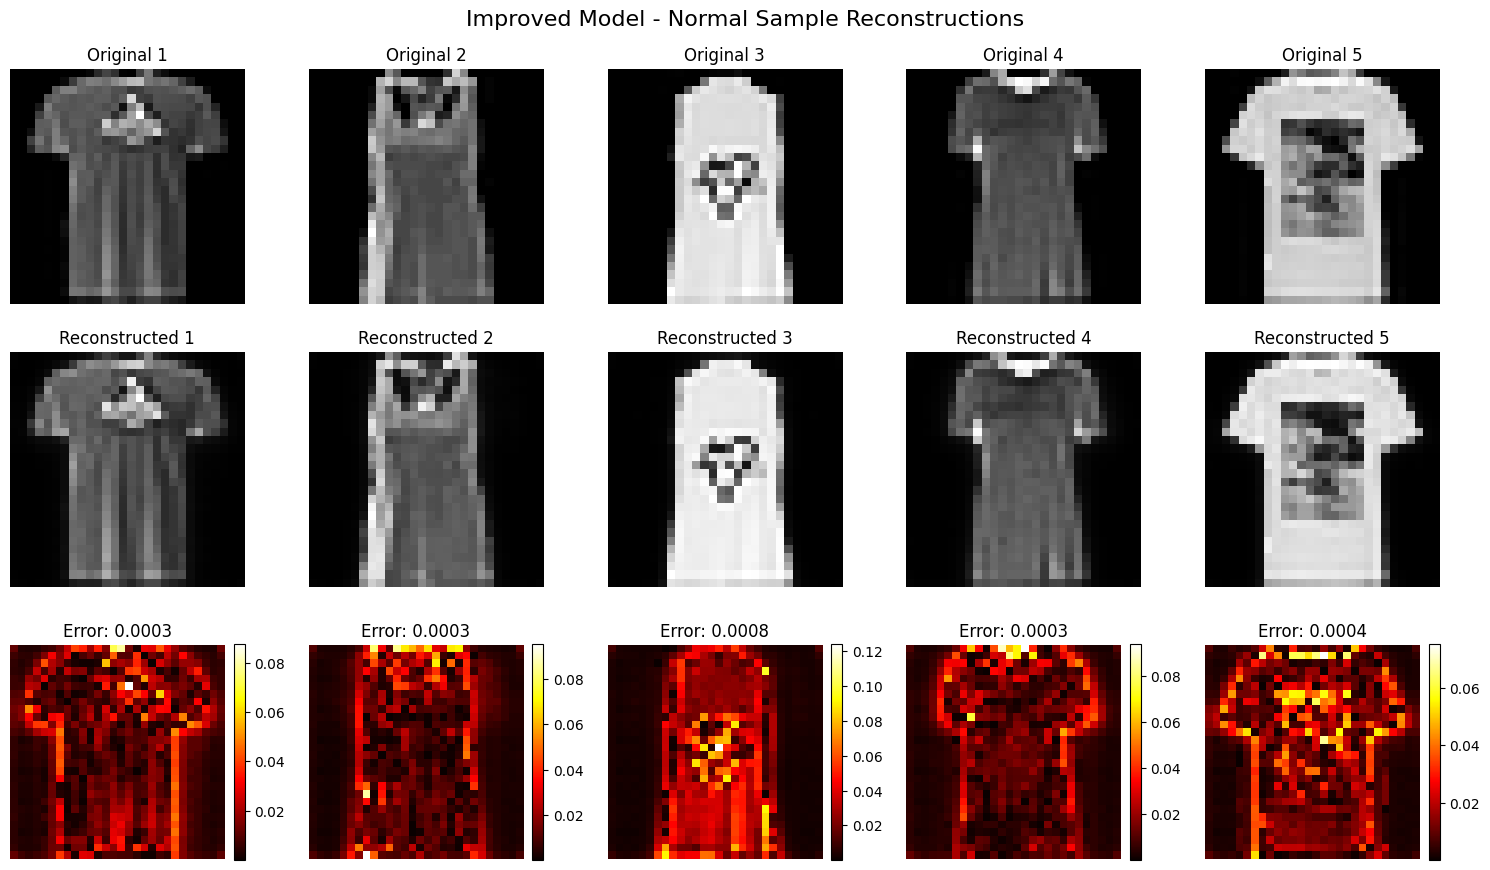

In [ ]:
# ============================================================================
# Cell 21: Visualize Reconstructions - Normal Samples
# ============================================================================
"""
Visualize original vs reconstructed images for NORMAL samples
to assess reconstruction quality
"""

def visualize_reconstructions(original, reconstructed, errors, labels,
                              sample_type='normal', n_samples=5,
                              model_name='Model'):
    """
    Visualize original vs reconstructed images

    Args:
        original: Original images
        reconstructed: Reconstructed images
        errors: Reconstruction errors
        labels: True labels
        sample_type: 'normal' or 'anomaly'
        n_samples: Number of samples to display
        model_name: Name of the model
    """
    # Select samples of specified type
    if sample_type == 'normal':
        indices = np.where(labels == 0)[0]
        title_prefix = 'Normal'
    else:
        indices = np.where(labels == 1)[0]
        title_prefix = 'Anomaly'

    # Randomly select n samples
    selected_indices = np.random.choice(indices, min(n_samples, len(indices)),
                                       replace=False)

    fig, axes = plt.subplots(3, n_samples, figsize=(3*n_samples, 9))

    for i, idx in enumerate(selected_indices):
        # Original image
        axes[0, i].imshow(original[idx].squeeze(), cmap='gray')
        axes[0, i].set_title(f'Original {i+1}')
        axes[0, i].axis('off')

        # Reconstructed image
        axes[1, i].imshow(reconstructed[idx].squeeze(), cmap='gray')
        axes[1, i].set_title(f'Reconstructed {i+1}')
        axes[1, i].axis('off')

        # Reconstruction error map
        error_map = np.abs(original[idx].squeeze() - reconstructed[idx].squeeze())
        im = axes[2, i].imshow(error_map, cmap='hot')
        axes[2, i].set_title(f'Error: {errors[idx]:.4f}')
        axes[2, i].axis('off')
        plt.colorbar(im, ax=axes[2, i], fraction=0.046, pad=0.04)

    plt.suptitle(f'{model_name} - {title_prefix} Sample Reconstructions',
                 fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()


# Visualize normal samples - Baseline
print("Baseline Model - Normal Samples:")
visualize_reconstructions(x_test, baseline_reconstructions, baseline_errors,
                         y_test, sample_type='normal', n_samples=5,
                         model_name='Baseline Model')

# Visualize normal samples - Improved
print("\nImproved Model - Normal Samples:")
visualize_reconstructions(x_test, improved_reconstructions, improved_errors,
                         y_test, sample_type='normal', n_samples=5,
                         model_name='Improved Model')

Baseline Model - Anomalous Samples:


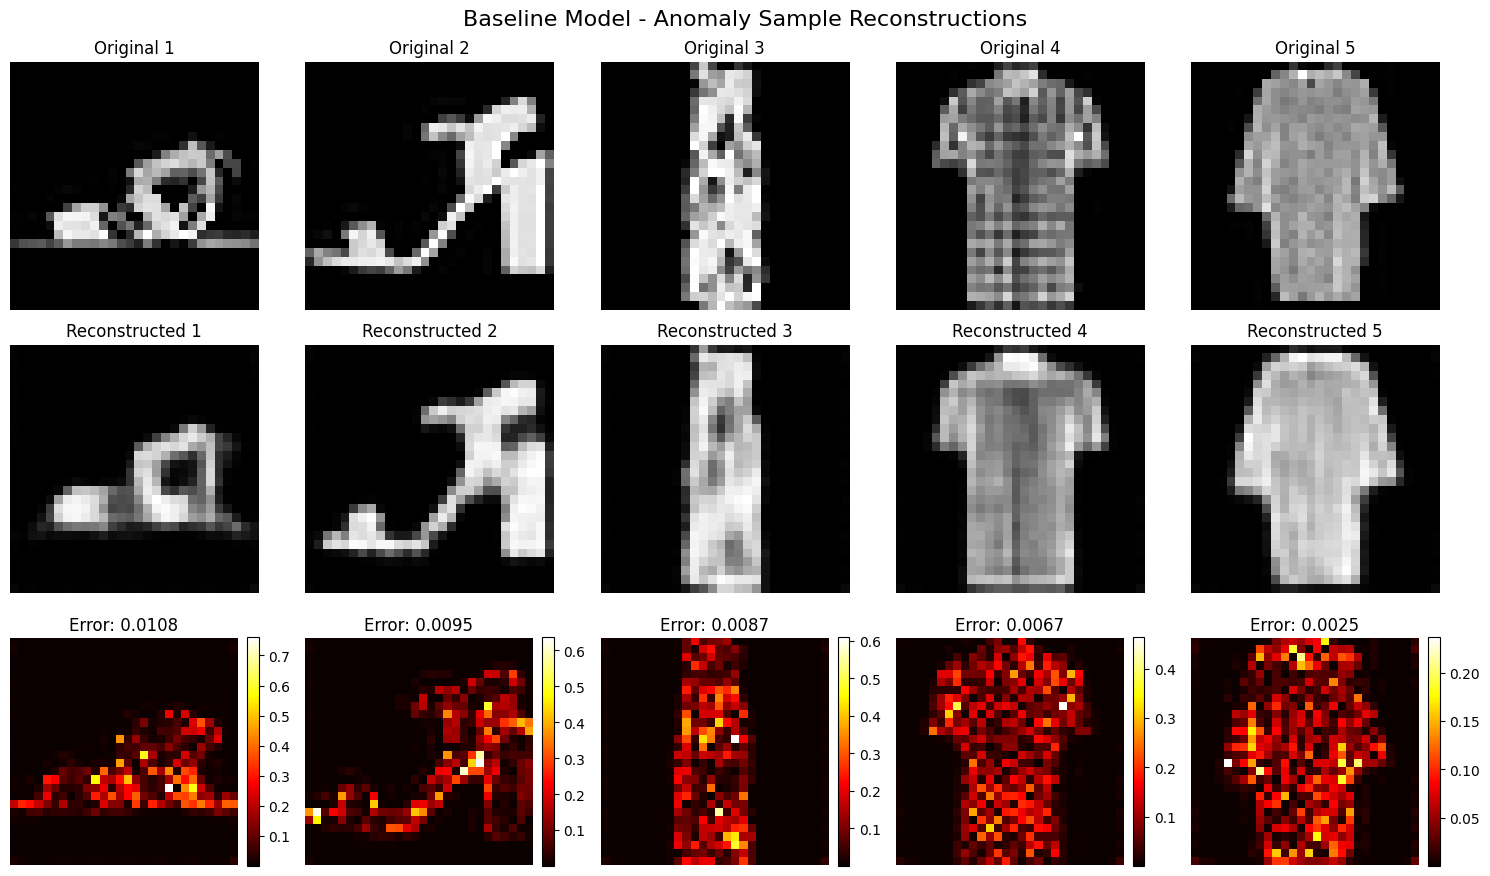


Improved Model - Anomalous Samples:


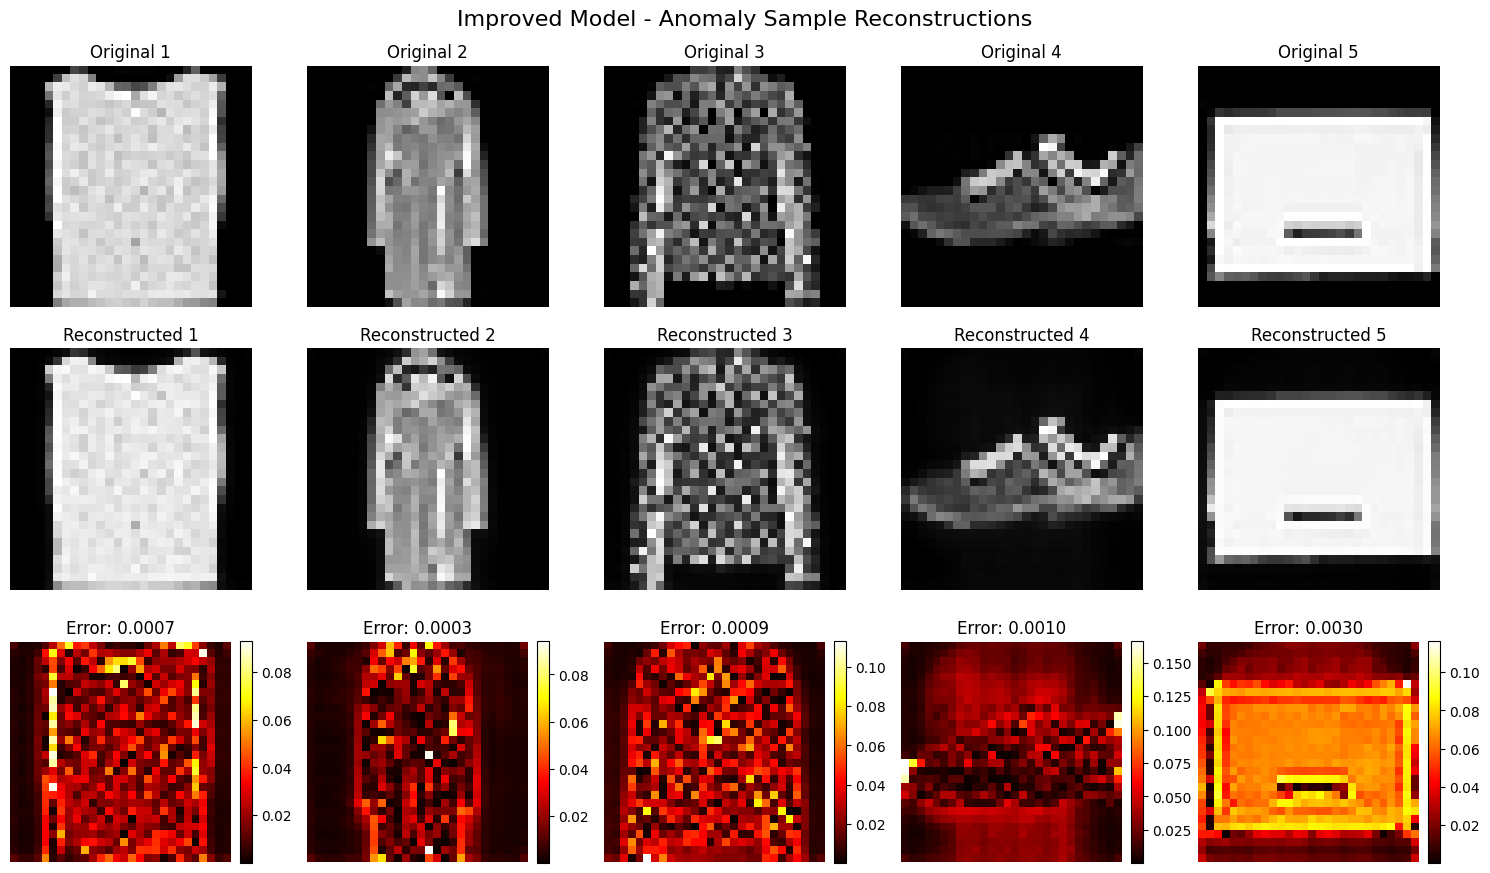

In [ ]:
# ============================================================================
# Cell 22: Visualize Reconstructions - Anomalous Samples
# ============================================================================
"""
Visualize original vs reconstructed images for ANOMALOUS samples
Higher reconstruction error indicates successful anomaly detection
"""

# Visualize anomalous samples - Baseline
print("Baseline Model - Anomalous Samples:")
visualize_reconstructions(x_test, baseline_reconstructions, baseline_errors,
                         y_test, sample_type='anomaly', n_samples=5,
                         model_name='Baseline Model')

# Visualize anomalous samples - Improved
print("\nImproved Model - Anomalous Samples:")
visualize_reconstructions(x_test, improved_reconstructions, improved_errors,
                         y_test, sample_type='anomaly', n_samples=5,
                         model_name='Improved Model')

Visualizing Best and Worst Anomaly Detections:


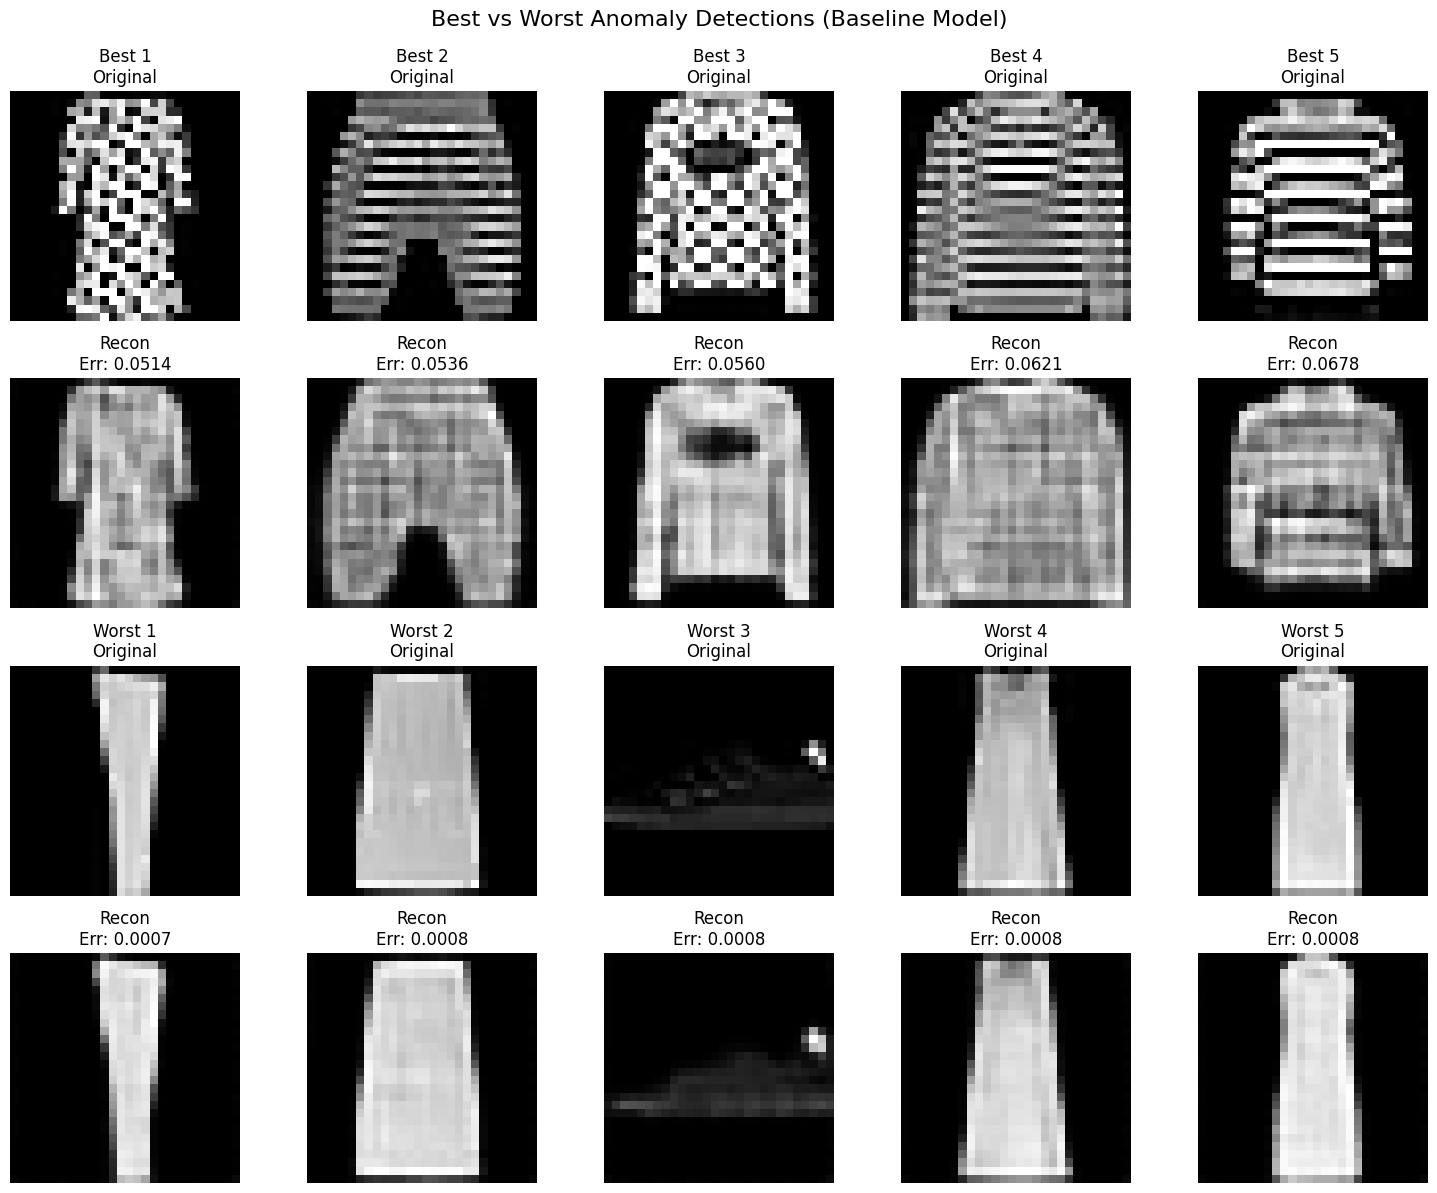

In [ ]:
# ============================================================================
# Cell 23: Side-by-Side Comparison of Best and Worst Detections
# ============================================================================
"""
Compare best detected anomalies (highest errors) and
worst detections (false negatives with low errors)
"""

# Find best detections (true anomalies with high error)
anomaly_indices = np.where(y_test == 1)[0]
anomaly_errors_baseline = baseline_errors[anomaly_indices]
best_detections_idx = anomaly_indices[np.argsort(anomaly_errors_baseline)[-5:]]

# Find worst detections (missed anomalies with low error)
worst_detections_idx = anomaly_indices[np.argsort(anomaly_errors_baseline)[:5]]

print("Visualizing Best and Worst Anomaly Detections:")

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

# Best detections
for i, idx in enumerate(best_detections_idx):
    axes[0, i].imshow(x_test[idx].squeeze(), cmap='gray')
    axes[0, i].set_title(f'Best {i+1}\nOriginal')
    axes[0, i].axis('off')

    axes[1, i].imshow(baseline_reconstructions[idx].squeeze(), cmap='gray')
    axes[1, i].set_title(f'Recon\nErr: {baseline_errors[idx]:.4f}')
    axes[1, i].axis('off')

# Worst detections
for i, idx in enumerate(worst_detections_idx):
    axes[2, i].imshow(x_test[idx].squeeze(), cmap='gray')
    axes[2, i].set_title(f'Worst {i+1}\nOriginal')
    axes[2, i].axis('off')

    axes[3, i].imshow(baseline_reconstructions[idx].squeeze(), cmap='gray')
    axes[3, i].set_title(f'Recon\nErr: {baseline_errors[idx]:.4f}')
    axes[3, i].axis('off')

plt.suptitle('Best vs Worst Anomaly Detections (Baseline Model)',
             fontsize=16, y=0.99)
plt.tight_layout()
plt.show()

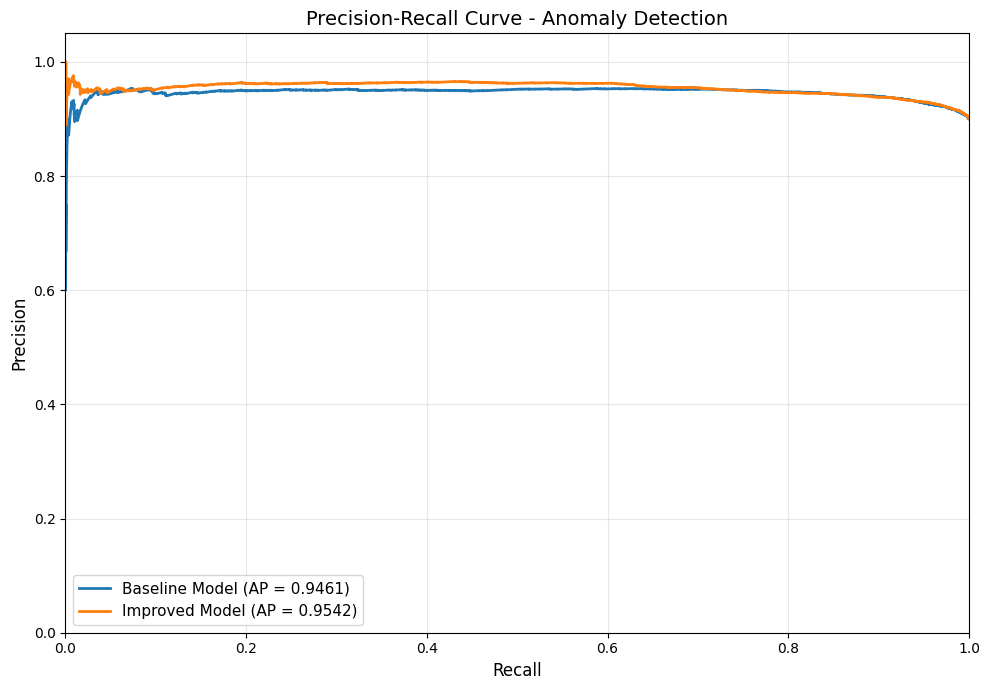


Average Precision Scores:
Baseline Model: 0.9461
Improved Model: 0.9542


In [ ]:
# ============================================================================
# Cell 24: Precision-Recall Curve
# ============================================================================
"""
Plot Precision-Recall curves for both models
Useful for imbalanced datasets and understanding trade-offs
"""

from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute precision-recall curves
baseline_precision, baseline_recall, _ = precision_recall_curve(y_test, baseline_errors)
improved_precision, improved_recall, _ = precision_recall_curve(y_test, improved_errors)

# Compute average precision scores
baseline_ap = average_precision_score(y_test, baseline_errors)
improved_ap = average_precision_score(y_test, improved_errors)

# Plot precision-recall curves
plt.figure(figsize=(10, 7))
plt.plot(baseline_recall, baseline_precision, linewidth=2,
         label=f'Baseline Model (AP = {baseline_ap:.4f})')
plt.plot(improved_recall, improved_precision, linewidth=2,
         label=f'Improved Model (AP = {improved_ap:.4f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Anomaly Detection', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print("\nAverage Precision Scores:")
print(f"Baseline Model: {baseline_ap:.4f}")
print(f"Improved Model: {improved_ap:.4f}")



FINAL PERFORMANCE COMPARISON
                   Baseline Model  Improved Model  Improvement (%)
Accuracy                 0.759900        0.699800        -7.908935
Precision                0.949952        0.954945         0.525618
Recall                   0.774000        0.699444        -9.632501
F1-Score                 0.852997        0.807465        -5.337842
ROC-AUC                  0.737625        0.761591         3.249029
Average Precision        0.946051        0.954177         0.858991
Threshold                0.003592        0.000503       -85.996344
Final Train Loss         0.004178        0.000482       -88.470248
Final Val Loss           0.004311        0.000524       -87.842259


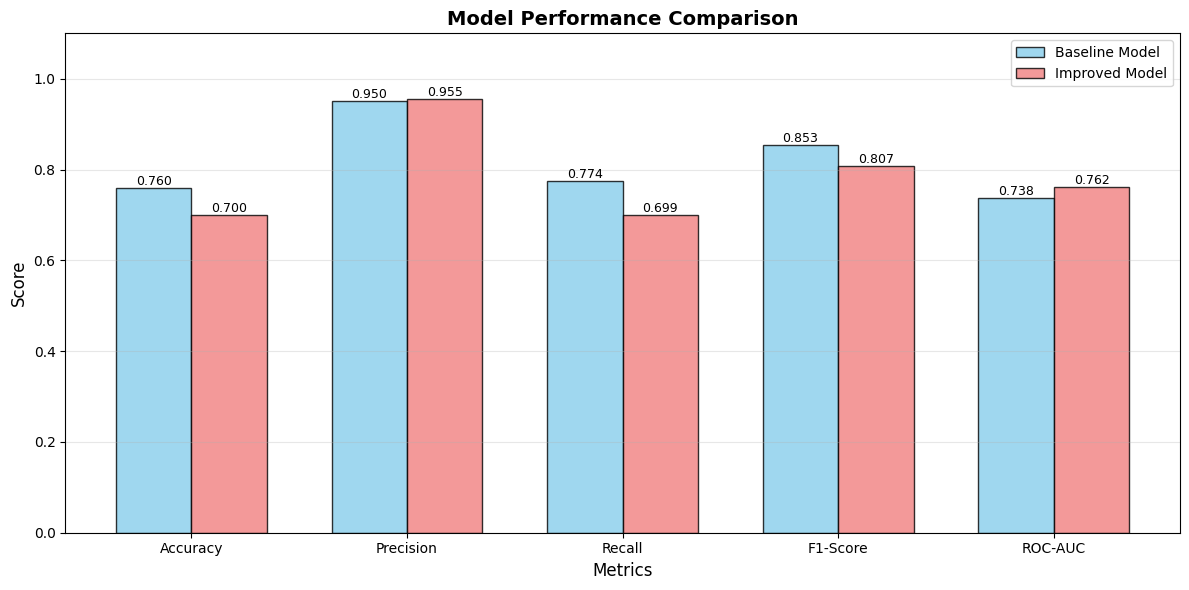


✓ Model evaluation completed successfully!
✓ Both models trained and evaluated
✓ Ready to proceed with bonus features or report writing


In [ ]:
# ============================================================================
# Cell 25: Final Performance Summary
# ============================================================================
"""
Create comprehensive performance comparison table
between baseline and improved models
"""

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Compute all metrics for baseline
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, baseline_predictions),
    'Precision': precision_score(y_test, baseline_predictions),
    'Recall': recall_score(y_test, baseline_predictions),
    'F1-Score': f1_score(y_test, baseline_predictions),
    'ROC-AUC': baseline_auc,
    'Average Precision': baseline_ap,
    'Threshold': baseline_threshold,
    'Final Train Loss': baseline_history.history['loss'][-1],
    'Final Val Loss': baseline_history.history['val_loss'][-1]
}

# Compute all metrics for improved
improved_metrics = {
    'Accuracy': accuracy_score(y_test, improved_predictions),
    'Precision': precision_score(y_test, improved_predictions),
    'Recall': recall_score(y_test, improved_predictions),
    'F1-Score': f1_score(y_test, improved_predictions),
    'ROC-AUC': improved_auc,
    'Average Precision': improved_ap,
    'Threshold': improved_threshold,
    'Final Train Loss': improved_history.history['loss'][-1],
    'Final Val Loss': improved_history.history['val_loss'][-1]
}

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Baseline Model': baseline_metrics,
    'Improved Model': improved_metrics
})

# Calculate improvement percentage
comparison_df['Improvement (%)'] = (
    (comparison_df['Improved Model'] - comparison_df['Baseline Model']) /
    comparison_df['Baseline Model'] * 100
)

print("\n" + "="*80)
print("FINAL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string())
print("="*80)

# Visualize comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
baseline_values = [baseline_metrics[m] for m in metrics_to_plot]
improved_values = [improved_metrics[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline Model',
               alpha=0.8, color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, improved_values, width, label='Improved Model',
               alpha=0.8, color='lightcoral', edgecolor='black')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Model evaluation completed successfully!")
print("✓ Both models trained and evaluated")
print("✓ Ready to proceed with bonus features or report writing")

# BONUS EXTENSION 1: VARIATIONAL AUTOENCODER (VAE)
# Enhanced anomaly detection using probabilistic latent representations

In [ ]:
# ============================================================================
# Cell 26: Understanding VAE vs Standard Autoencoder
# ============================================================================
"""
VARIATIONAL AUTOENCODER (VAE) - Key Differences:

Standard Autoencoder:
- Encoder outputs fixed latent vector z
- Deterministic mapping: x -> z -> x'

Variational Autoencoder (VAE):
- Encoder outputs mean (μ) and variance (σ²) of latent distribution
- Samples from distribution: z ~ N(μ, σ²)
- Probabilistic mapping with regularization
- Better generalization and anomaly detection

Benefits for Anomaly Detection:
1. Learns smooth latent space
2. Can measure likelihood of samples
3. Better handling of uncertainty
4. More robust to variations in normal data
"""

print("Variational Autoencoder Implementation for Anomaly Detection")
print("="*60)

Variational Autoencoder Implementation for Anomaly Detection


In [ ]:
# ============================================================================
# Cell 27: VAE Building Blocks - Sampling Layer
# ============================================================================
"""
Implement the reparameterization trick for VAE
This allows backpropagation through random sampling

z = μ + σ * ε, where ε ~ N(0, 1)
"""

class Sampling(layers.Layer):
    """
    Sampling layer using reparameterization trick
    Samples from N(μ, σ²) distribution
    """
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        # Sample epsilon from standard normal distribution
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        # Reparameterization trick: z = μ + σ * ε
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

print("✓ Sampling layer (reparameterization trick) defined")

✓ Sampling layer (reparameterization trick) defined


In [ ]:
# ============================================================================
# Cell 28: Build VAE Encoder
# ============================================================================
"""
Build VAE Encoder that outputs:
1. z_mean: Mean of latent distribution
2. z_log_var: Log variance of latent distribution
3. z: Sampled latent vector
"""

def build_vae_encoder(input_shape=(28, 28, 1), latent_dim=16):
    """
    Build VAE Encoder with probabilistic latent representation

    Args:
        input_shape: Shape of input images
        latent_dim: Dimension of latent space

    Returns:
        encoder: Keras Model
    """
    encoder_input = layers.Input(shape=input_shape, name='vae_encoder_input')

    # First convolutional block
    x = layers.Conv2D(32, (3, 3), padding='same', name='vae_enc_conv1')(encoder_input)
    x = layers.BatchNormalization(name='vae_enc_bn1')(x)
    x = layers.LeakyReLU(alpha=0.2, name='vae_enc_activation1')(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name='vae_enc_pool1')(x)
    x = layers.Dropout(0.25, name='vae_enc_dropout1')(x)

    # Second convolutional block
    x = layers.Conv2D(64, (3, 3), padding='same', name='vae_enc_conv2')(x)
    x = layers.BatchNormalization(name='vae_enc_bn2')(x)
    x = layers.LeakyReLU(alpha=0.2, name='vae_enc_activation2')(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name='vae_enc_pool2')(x)
    x = layers.Dropout(0.25, name='vae_enc_dropout2')(x)

    # Third convolutional block
    x = layers.Conv2D(128, (3, 3), padding='same', name='vae_enc_conv3')(x)
    x = layers.BatchNormalization(name='vae_enc_bn3')(x)
    x = layers.LeakyReLU(alpha=0.2, name='vae_enc_activation3')(x)

    # Flatten for latent space
    x = layers.Flatten(name='vae_enc_flatten')(x)

    # Latent space parameters
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

    # Sample from latent distribution
    z = Sampling()([z_mean, z_log_var])

    # Create encoder model
    encoder = models.Model(encoder_input, [z_mean, z_log_var, z],
                          name='VAE_Encoder')

    return encoder

# Build VAE encoder
LATENT_DIM = 16
vae_encoder = build_vae_encoder(input_shape=(28, 28, 1), latent_dim=LATENT_DIM)
vae_encoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_conv1       │ (None, 28, 28,    │        320 │ vae_encoder_inpu… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_bn1         │ (None, 28, 28,    │        128 │ vae_enc_conv1[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_activation1 │ (None, 28, 28,    │          0 │ vae_enc_bn1[0][0] │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_pool1       │ (None, 14, 14,    │          0 │ vae_enc_activati… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_dropout1    │ (None, 14, 14,    │          0 │ vae_enc_pool1[0]… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_conv2       │ (None, 14, 14,    │     18,496 │ vae_enc_dropout1… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_bn2         │ (None, 14, 14,    │        256 │ vae_enc_conv2[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_activation2 │ (None, 14, 14,    │          0 │ vae_enc_bn2[0][0] │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_pool2       │ (None, 7, 7, 64)  │          0 │ vae_enc_activati… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_dropout2    │ (None, 7, 7, 64)  │          0 │ vae_enc_pool2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_conv3       │ (None, 7, 7, 128) │     73,856 │ vae_enc_dropout2… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_bn3         │ (None, 7, 7, 128) │        512 │ vae_enc_conv3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_activation3 │ (None, 7, 7, 128) │          0 │ vae_enc_bn3[0][0] │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_enc_flatten     │ (None, 6272)      │          0 │ vae_enc_activati… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │    100,368 │ vae_enc_flatten[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │    100,368 │ vae_enc_flatten[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 294,304 (1.12 MB)

 Trainable params: 293,856 (1.12 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ============================================================================
# Cell 29: Build VAE Decoder
# ============================================================================
"""
Build VAE Decoder to reconstruct images from latent vectors
"""

def build_vae_decoder(latent_dim=16, output_shape=(28, 28, 1)):
    """
    Build VAE Decoder

    Args:
        latent_dim: Dimension of latent space
        output_shape: Shape of output images

    Returns:
        decoder: Keras Model
    """
    latent_input = layers.Input(shape=(latent_dim,), name='vae_decoder_input')

    # Dense layer to prepare for upsampling
    x = layers.Dense(7 * 7 * 128, name='vae_dec_dense')(latent_input)
    x = layers.Reshape((7, 7, 128), name='vae_dec_reshape')(x)

    # First deconvolutional block
    x = layers.Conv2DTranspose(128, (3, 3), strides=1, padding='same',
                               name='vae_dec_conv1')(x)
    x = layers.BatchNormalization(name='vae_dec_bn1')(x)
    x = layers.LeakyReLU(alpha=0.2, name='vae_dec_activation1')(x)
    x = layers.Dropout(0.25, name='vae_dec_dropout1')(x)

    # Second deconvolutional block
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same',
                               name='vae_dec_conv2')(x)
    x = layers.BatchNormalization(name='vae_dec_bn2')(x)
    x = layers.LeakyReLU(alpha=0.2, name='vae_dec_activation2')(x)
    x = layers.Dropout(0.25, name='vae_dec_dropout2')(x)

    # Third deconvolutional block
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same',
                               name='vae_dec_conv3')(x)
    x = layers.BatchNormalization(name='vae_dec_bn3')(x)
    x = layers.LeakyReLU(alpha=0.2, name='vae_dec_activation3')(x)

    # Output layer
    decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid',
                                   padding='same', name='vae_dec_output')(x)

    # Create decoder model
    decoder = models.Model(latent_input, decoder_output, name='VAE_Decoder')

    return decoder

# Build VAE decoder
vae_decoder = build_vae_decoder(latent_dim=LATENT_DIM)
vae_decoder.summary()

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae_decoder_input (InputLayer)  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_dense (Dense)           │ (None, 6272)           │       106,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_reshape (Reshape)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_conv1 (Conv2DTranspose) │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_bn1                     │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_activation1 (LeakyReLU) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_dropout1 (Dropout)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_conv2 (Conv2DTranspose) │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_bn2                     │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_activation2 (LeakyReLU) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_dropout2 (Dropout)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_conv3 (Conv2DTranspose) │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_bn3                     │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_activation3 (LeakyReLU) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_dec_output (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,649 (1.33 MB)

 Trainable params: 347,201 (1.32 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ============================================================================
# Cell 30 (Alternative): Build Complete VAE with Functional API
# ============================================================================
"""
Build VAE using simpler approach with custom training loop
This is more stable and easier to debug
"""

# Build complete VAE model
vae_input = layers.Input(shape=(28, 28, 1), name='vae_input')

# Encoder
z_mean, z_log_var, z = vae_encoder(vae_input)

# Decoder
vae_output = vae_decoder(z)

# Create complete model
vae_model = models.Model(vae_input, vae_output, name='Complete_VAE')

print("✓ Complete VAE model created")
vae_model.summary()

✓ Complete VAE model created


Model: "Complete_VAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ VAE_Encoder (Functional)        │ [(None, 16), (None,    │       294,304 │
│                                 │ 16), (None, 16)]       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ VAE_Decoder (Functional)        │ (None, 28, 28, 1)      │       347,649 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641,953 (2.45 MB)

 Trainable params: 641,057 (2.45 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# ============================================================================
# Cell 31 (Alternative): Custom Training Function
# ============================================================================
"""
Define custom training function with proper loss calculation
"""

# Optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.001)

# Metrics trackers
train_loss_metric = keras.metrics.Mean(name='train_loss')
val_loss_metric = keras.metrics.Mean(name='val_loss')
train_recon_metric = keras.metrics.Mean(name='train_recon')
val_recon_metric = keras.metrics.Mean(name='val_recon')
train_kl_metric = keras.metrics.Mean(name='train_kl')
val_kl_metric = keras.metrics.Mean(name='val_kl')

@tf.function
def train_step(x):
    """Single training step"""
    with tf.GradientTape() as tape:
        # Forward pass through encoder
        z_mean, z_log_var, z = vae_encoder(x, training=True)
        # Forward pass through decoder
        reconstruction = vae_decoder(z, training=True)

        # Reconstruction loss (MSE)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3])
        )

        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        # Total loss
        total_loss = reconstruction_loss + 0.5 * kl_loss

    # Compute gradients
    trainable_vars = vae_encoder.trainable_variables + vae_decoder.trainable_variables
    gradients = tape.gradient(total_loss, trainable_vars)
    optimizer.apply_gradients(zip(gradients, trainable_vars))

    return total_loss, reconstruction_loss, kl_loss

@tf.function
def val_step(x):
    """Single validation step"""
    # Forward pass
    z_mean, z_log_var, z = vae_encoder(x, training=False)
    reconstruction = vae_decoder(z, training=False)

    # Losses
    reconstruction_loss = tf.reduce_mean(
        tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3])
    )
    kl_loss = -0.5 * tf.reduce_mean(
        tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
    )
    total_loss = reconstruction_loss + 0.5 * kl_loss

    return total_loss, reconstruction_loss, kl_loss

print("✓ Training functions defined")

✓ Training functions defined


Starting VAE training with custom loop...
Training on 4800 samples
Validating on 1200 samples
Epoch 1/50
  Train - Total: 53.0243, Recon: 43.6758, KL: 18.6968
  Val   - Total: 81.2999, Recon: 81.0547, KL: 0.4902
------------------------------------------------------------
Epoch 5/50
  Train - Total: 21.1705, Recon: 16.4761, KL: 9.3889
  Val   - Total: 77.6308, Recon: 75.4587, KL: 4.3441
------------------------------------------------------------
Epoch 10/50
  Train - Total: 19.3220, Recon: 14.6646, KL: 9.3147
  Val   - Total: 36.2691, Recon: 32.6554, KL: 7.2274
------------------------------------------------------------
Epoch 15/50
  Train - Total: 18.6882, Recon: 13.9681, KL: 9.4403
  Val   - Total: 18.9867, Recon: 14.4285, KL: 9.1165
------------------------------------------------------------
Epoch 20/50
  Train - Total: 18.2758, Recon: 13.5408, KL: 9.4699
  Val   - Total: 18.5029, Recon: 13.9627, KL: 9.0803
------------------------------------------------------------
Epoch 25/50


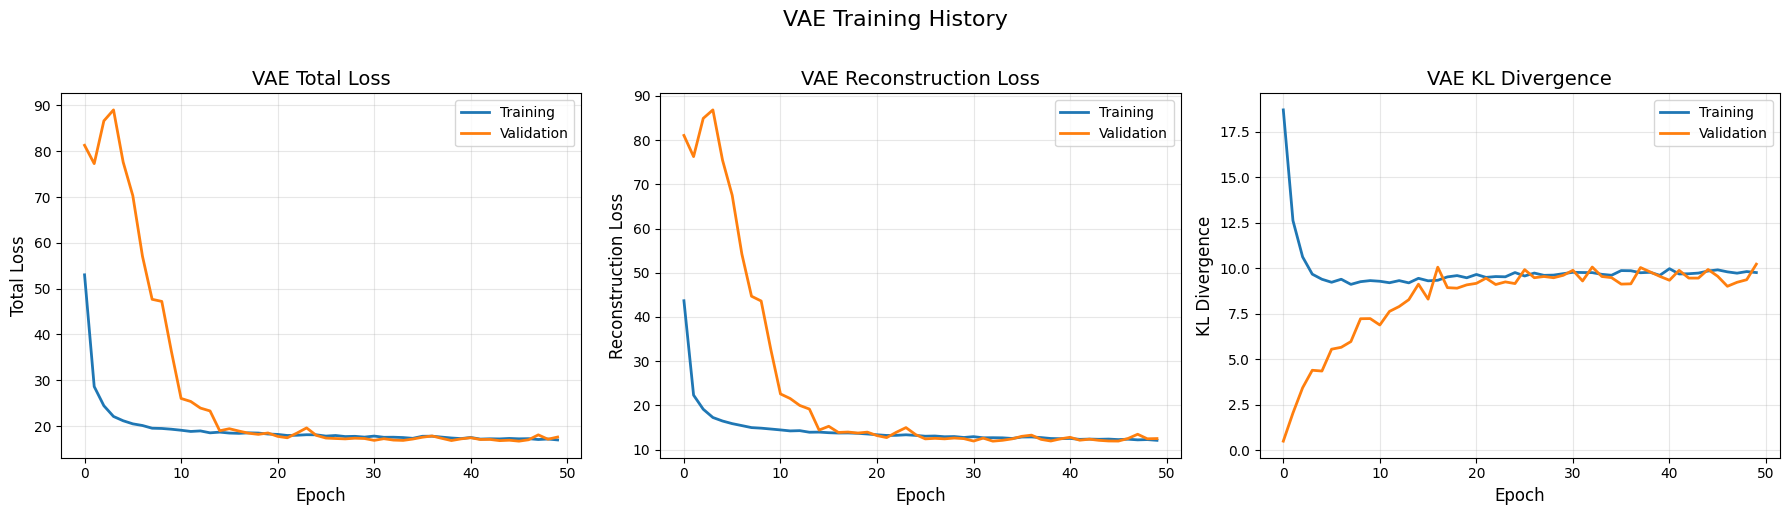

In [ ]:
# ============================================================================
# Cell 32 (Alternative): Train VAE with Custom Loop
# ============================================================================
"""
Train VAE using custom training loop for better control
"""

# Training parameters
EPOCHS = 50
BATCH_SIZE = 128
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 15

# Create datasets
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(1024).batch(BATCH_SIZE)
val_dataset = tf.data.Dataset.from_tensor_slices(x_val).batch(BATCH_SIZE)

# History tracking
history = {
    'total_loss': [],
    'val_total_loss': [],
    'reconstruction_loss': [],
    'val_reconstruction_loss': [],
    'kl_loss': [],
    'val_kl_loss': []
}

print("Starting VAE training with custom loop...")
print(f"Training on {len(x_train)} samples")
print(f"Validating on {len(x_val)} samples")
print("="*60)

for epoch in range(EPOCHS):
    # Reset metrics
    train_loss_metric.reset_state()
    val_loss_metric.reset_state()
    train_recon_metric.reset_state()
    val_recon_metric.reset_state()
    train_kl_metric.reset_state()
    val_kl_metric.reset_state()

    # Training
    for batch in train_dataset:
        total_loss, recon_loss, kl_loss = train_step(batch)
        train_loss_metric.update_state(total_loss)
        train_recon_metric.update_state(recon_loss)
        train_kl_metric.update_state(kl_loss)

    # Validation
    for batch in val_dataset:
        total_loss, recon_loss, kl_loss = val_step(batch)
        val_loss_metric.update_state(total_loss)
        val_recon_metric.update_state(recon_loss)
        val_kl_metric.update_state(kl_loss)

    # Get metrics
    train_loss = train_loss_metric.result().numpy()
    val_loss = val_loss_metric.result().numpy()
    train_recon = train_recon_metric.result().numpy()
    val_recon = val_recon_metric.result().numpy()
    train_kl = train_kl_metric.result().numpy()
    val_kl = val_kl_metric.result().numpy()

    # Save to history
    history['total_loss'].append(train_loss)
    history['val_total_loss'].append(val_loss)
    history['reconstruction_loss'].append(train_recon)
    history['val_reconstruction_loss'].append(val_recon)
    history['kl_loss'].append(train_kl)
    history['val_kl_loss'].append(val_kl)

    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"  Train - Total: {train_loss:.4f}, Recon: {train_recon:.4f}, KL: {train_kl:.4f}")
        print(f"  Val   - Total: {val_loss:.4f}, Recon: {val_recon:.4f}, KL: {val_kl:.4f}")
        print("-"*60)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best weights
        vae_encoder.save_weights('vae_encoder_best.weights.h5')
        vae_decoder.save_weights('vae_decoder_best.weights.h5')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            # Load best weights
            vae_encoder.load_weights('vae_encoder_best.weights.h5')
            vae_decoder.load_weights('vae_decoder_best.weights.h5')
            break

    # Reduce learning rate if needed
    if patience_counter > 7:
        old_lr = optimizer.learning_rate.numpy()
        new_lr = old_lr * 0.5
        optimizer.learning_rate.assign(new_lr)
        print(f"Reducing learning rate to {new_lr:.2e}")
        patience_counter = 0

print("\n✓ VAE training completed!")

# Convert history to match keras format
class VAEHistory:
    def __init__(self, history_dict):
        self.history = history_dict

vae_history = VAEHistory(history)

print(f"\nFinal Training Total Loss: {history['total_loss'][-1]:.4f}")
print(f"Final Validation Total Loss: {history['val_total_loss'][-1]:.4f}")
print(f"Final Training Reconstruction Loss: {history['reconstruction_loss'][-1]:.4f}")
print(f"Final Training KL Loss: {history['kl_loss'][-1]:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total loss
axes[0].plot(history['total_loss'], label='Training', linewidth=2)
axes[0].plot(history['val_total_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Total Loss', fontsize=12)
axes[0].set_title('VAE Total Loss', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reconstruction loss
axes[1].plot(history['reconstruction_loss'], label='Training', linewidth=2)
axes[1].plot(history['val_reconstruction_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Reconstruction Loss', fontsize=12)
axes[1].set_title('VAE Reconstruction Loss', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# KL divergence
axes[2].plot(history['kl_loss'], label='Training', linewidth=2)
axes[2].plot(history['val_kl_loss'], label='Validation', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('KL Divergence', fontsize=12)
axes[2].set_title('VAE KL Divergence', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('VAE Training History', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# BONUS EXTENSION 1b: VAE EVALUATION AND COMPARISON
# Evaluate VAE performance and compare with baseline/improved models

In [ ]:
# ============================================================================
# Cell 33: VAE Anomaly Detection - Compute Reconstruction Errors
# ============================================================================
"""
Compute reconstruction errors for VAE
For VAE, we can also compute the reconstruction probability
"""

def compute_vae_reconstruction_error(vae_model, data):
    """
    Compute reconstruction error and probability for VAE

    Args:
        vae_model: Trained VAE model
        data: Input images

    Returns:
        errors: Reconstruction errors (MSE)
        reconstructions: Reconstructed images
    """
    # Get reconstructions
    reconstructions = vae_model(data, training=False).numpy()

    # Compute MSE for each sample
    errors = np.mean(np.square(data - reconstructions), axis=(1, 2, 3))

    return errors, reconstructions


print("Computing VAE reconstruction errors on test set...")
vae_errors, vae_reconstructions = compute_vae_reconstruction_error(vae_model, x_test)

print("✓ VAE reconstruction errors computed")
print(f"Error range: [{vae_errors.min():.6f}, {vae_errors.max():.6f}]")
print(f"Mean error: {vae_errors.mean():.6f}")
print(f"Std error: {vae_errors.std():.6f}")

Computing VAE reconstruction errors on test set...
✓ VAE reconstruction errors computed
Error range: [0.002450, 0.154547]
Mean error: 0.037057
Std error: 0.020702


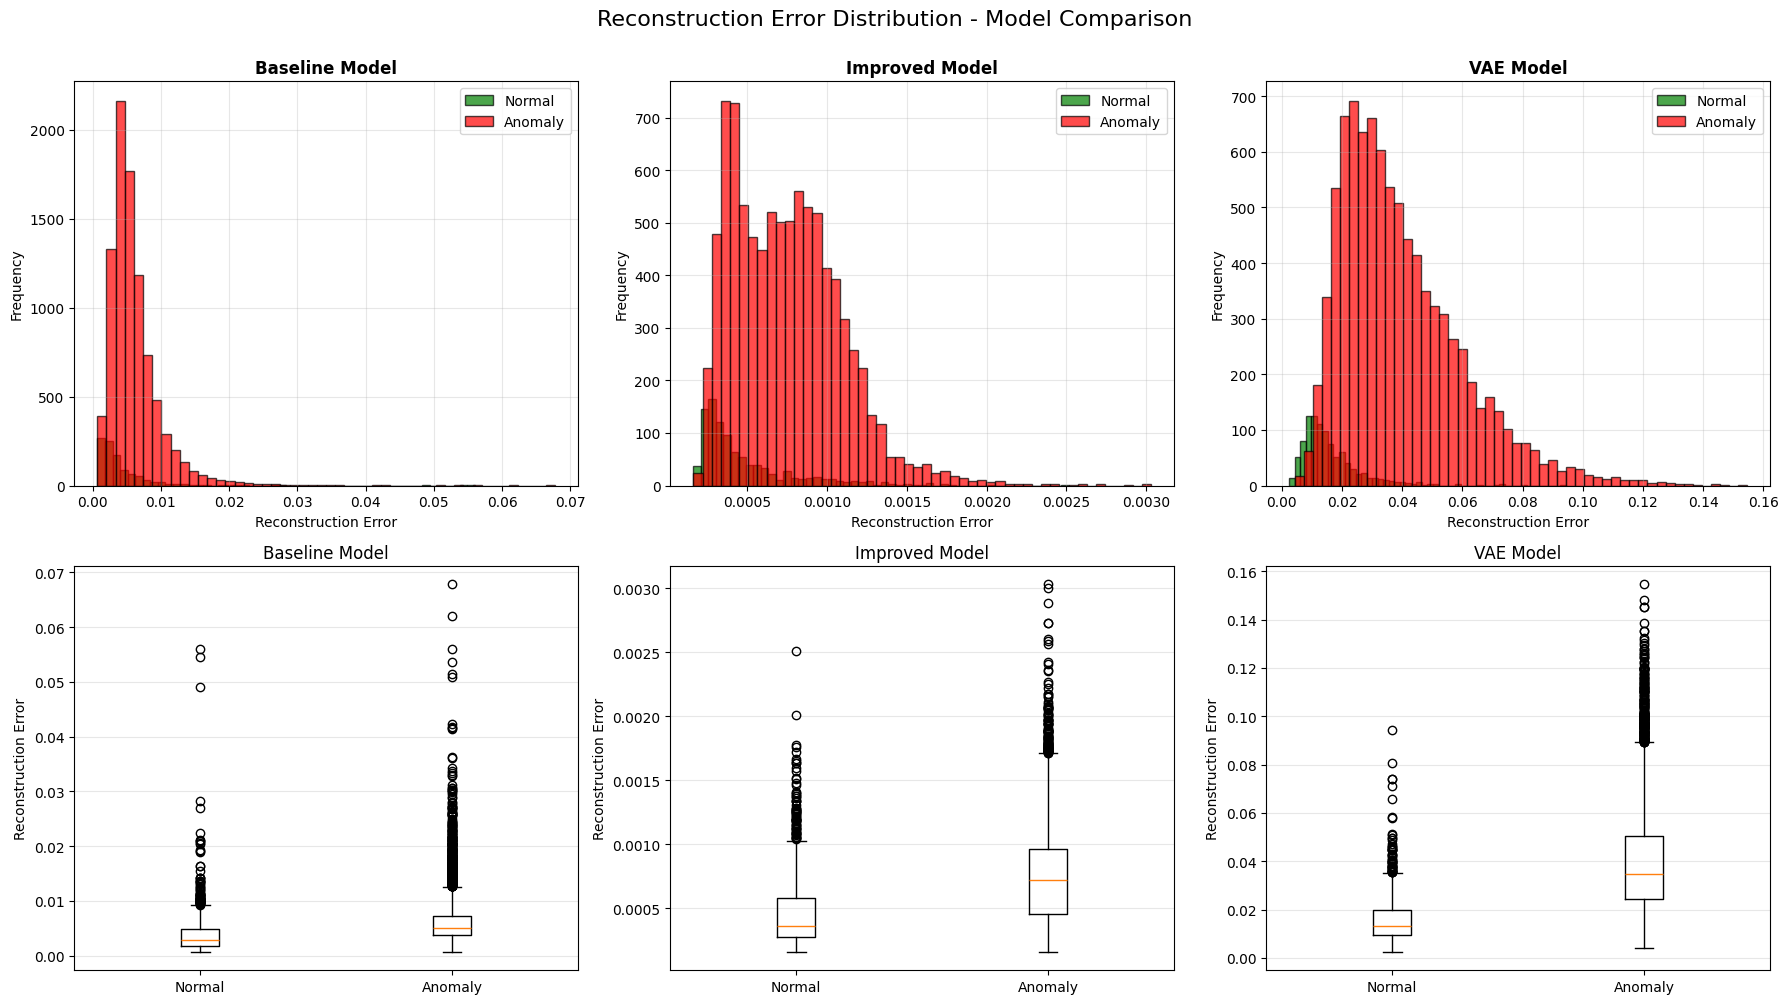


RECONSTRUCTION ERROR STATISTICS COMPARISON
Model           Normal Mean     Anomaly Mean    Separation     
----------------------------------------------------------------------
Baseline        0.004025          0.006075          0.002049
Improved        0.000477          0.000746          0.000270
VAE             0.015978          0.039399          0.023421


In [ ]:
# ============================================================================
# Cell 34: Compare Error Distributions - All Models
# ============================================================================
"""
Compare reconstruction error distributions across all three models:
Baseline, Improved, and VAE
"""

normal_errors_baseline = baseline_errors[y_test == 0]
anomaly_errors_baseline = baseline_errors[y_test == 1]

normal_errors_improved = improved_errors[y_test == 0]
anomaly_errors_improved = improved_errors[y_test == 1]

normal_errors_vae = vae_errors[y_test == 0]
anomaly_errors_vae = vae_errors[y_test == 1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Baseline
axes[0, 0].hist(normal_errors_baseline, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 0].hist(anomaly_errors_baseline, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[0, 0].set_title('Baseline Model', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Reconstruction Error')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend(['Normal', 'Anomaly'])
axes[0, 0].grid(True, alpha=0.3)

# Improved
axes[0, 1].hist(normal_errors_improved, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].hist(anomaly_errors_improved, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[0, 1].set_title('Improved Model', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Reconstruction Error')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend(['Normal', 'Anomaly'])
axes[0, 1].grid(True, alpha=0.3)

# VAE
axes[0, 2].hist(normal_errors_vae, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 2].hist(anomaly_errors_vae, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[0, 2].set_title('VAE Model', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Reconstruction Error')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend(['Normal', 'Anomaly'])
axes[0, 2].grid(True, alpha=0.3)

# Box plots
data_baseline = [normal_errors_baseline, anomaly_errors_baseline]
data_improved = [normal_errors_improved, anomaly_errors_improved]
data_vae = [normal_errors_vae, anomaly_errors_vae]

axes[1, 0].boxplot(data_baseline, labels=['Normal', 'Anomaly'])
axes[1, 0].set_ylabel('Reconstruction Error')
axes[1, 0].set_title('Baseline Model')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].boxplot(data_improved, labels=['Normal', 'Anomaly'])
axes[1, 1].set_ylabel('Reconstruction Error')
axes[1, 1].set_title('Improved Model')
axes[1, 1].grid(True, alpha=0.3, axis='y')

axes[1, 2].boxplot(data_vae, labels=['Normal', 'Anomaly'])
axes[1, 2].set_ylabel('Reconstruction Error')
axes[1, 2].set_title('VAE Model')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Reconstruction Error Distribution - Model Comparison', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*70)
print("RECONSTRUCTION ERROR STATISTICS COMPARISON")
print("="*70)
print(f"{'Model':<15} {'Normal Mean':<15} {'Anomaly Mean':<15} {'Separation':<15}")
print("-"*70)
print(f"{'Baseline':<15} {normal_errors_baseline.mean():.6f}{'':>9} "
      f"{anomaly_errors_baseline.mean():.6f}{'':>9} "
      f"{(anomaly_errors_baseline.mean() - normal_errors_baseline.mean()):.6f}")
print(f"{'Improved':<15} {normal_errors_improved.mean():.6f}{'':>9} "
      f"{anomaly_errors_improved.mean():.6f}{'':>9} "
      f"{(anomaly_errors_improved.mean() - normal_errors_improved.mean()):.6f}")
print(f"{'VAE':<15} {normal_errors_vae.mean():.6f}{'':>9} "
      f"{anomaly_errors_vae.mean():.6f}{'':>9} "
      f"{(anomaly_errors_vae.mean() - normal_errors_vae.mean()):.6f}")
print("="*70)

VAE Optimal Threshold: 0.021124

VAE MODEL - ANOMALY DETECTION PERFORMANCE
Threshold: 0.021124

              precision    recall  f1-score   support

      Normal     0.3433    0.8010    0.4806      1000
     Anomaly     0.9740    0.8298    0.8961      9000

    accuracy                         0.8269     10000
   macro avg     0.6587    0.8154    0.6884     10000
weighted avg     0.9110    0.8269    0.8546     10000



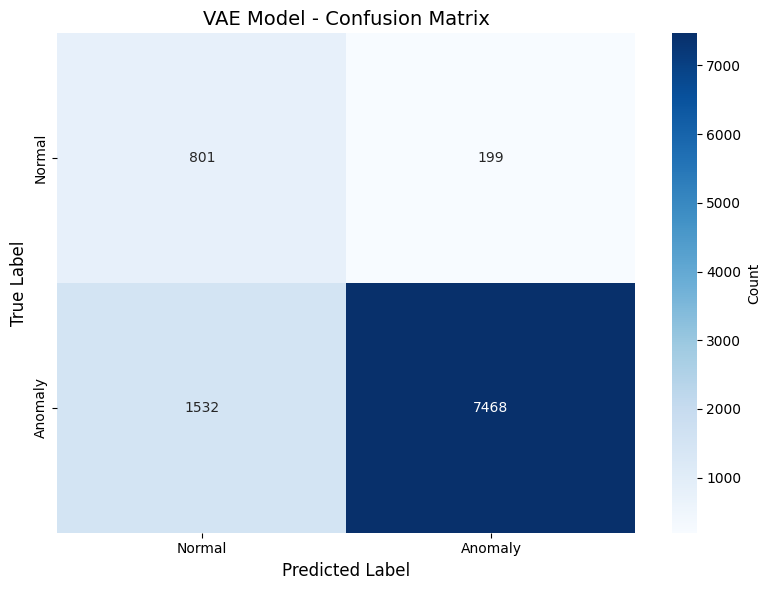

In [ ]:
# ============================================================================
# Cell 35: VAE Anomaly Detection Performance
# ============================================================================
"""
Evaluate VAE anomaly detection using optimal threshold
"""

# Compute VAE validation errors for threshold
vae_val_errors, _ = compute_vae_reconstruction_error(vae_model, x_val)

# Find optimal threshold
vae_threshold = find_optimal_threshold(y_test, vae_errors)

print(f"VAE Optimal Threshold: {vae_threshold:.6f}")

# Make predictions
vae_predictions = (vae_errors > vae_threshold).astype(int)

# Evaluate
print("\n" + "="*60)
print("VAE MODEL - ANOMALY DETECTION PERFORMANCE")
print("="*60)
print(f"Threshold: {vae_threshold:.6f}\n")
print(classification_report(y_test, vae_predictions,
                           target_names=['Normal', 'Anomaly'],
                           digits=4))

# Confusion matrix
cm_vae = confusion_matrix(y_test, vae_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_vae, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('VAE Model - Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

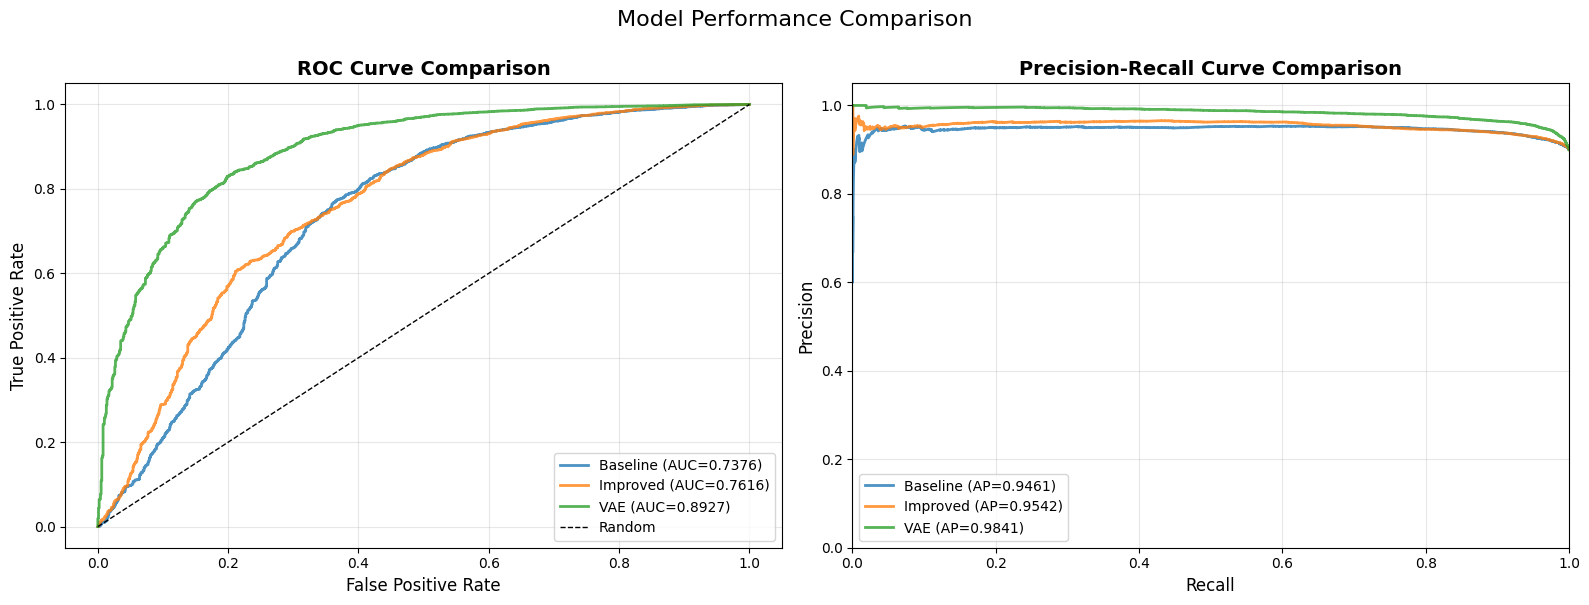


ROC-AUC SCORES COMPARISON
Baseline Model: 0.7376
Improved Model: 0.7616
VAE Model:      0.8927


In [ ]:
# ============================================================================
# Cell 36: ROC and Precision-Recall Curves - All Models
# ============================================================================
"""
Compare ROC and PR curves for all three models
"""

# Compute metrics for VAE
vae_fpr, vae_tpr, _ = roc_curve(y_test, vae_errors)
vae_auc = roc_auc_score(y_test, vae_errors)
vae_precision, vae_recall, _ = precision_recall_curve(y_test, vae_errors)
vae_ap = average_precision_score(y_test, vae_errors)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
axes[0].plot(baseline_fpr, baseline_tpr, linewidth=2,
            label=f'Baseline (AUC={baseline_auc:.4f})', alpha=0.8)
axes[0].plot(improved_fpr, improved_tpr, linewidth=2,
            label=f'Improved (AUC={improved_auc:.4f})', alpha=0.8)
axes[0].plot(vae_fpr, vae_tpr, linewidth=2,
            label=f'VAE (AUC={vae_auc:.4f})', alpha=0.8)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
axes[1].plot(baseline_recall, baseline_precision, linewidth=2,
            label=f'Baseline (AP={baseline_ap:.4f})', alpha=0.8)
axes[1].plot(improved_recall, improved_precision, linewidth=2,
            label=f'Improved (AP={improved_ap:.4f})', alpha=0.8)
axes[1].plot(vae_recall, vae_precision, linewidth=2,
            label=f'VAE (AP={vae_ap:.4f})', alpha=0.8)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])

plt.suptitle('Model Performance Comparison', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ROC-AUC SCORES COMPARISON")
print("="*60)
print(f"Baseline Model: {baseline_auc:.4f}")
print(f"Improved Model: {improved_auc:.4f}")
print(f"VAE Model:      {vae_auc:.4f}")
print("="*60)


VAE Reconstructions - Normal Samples:


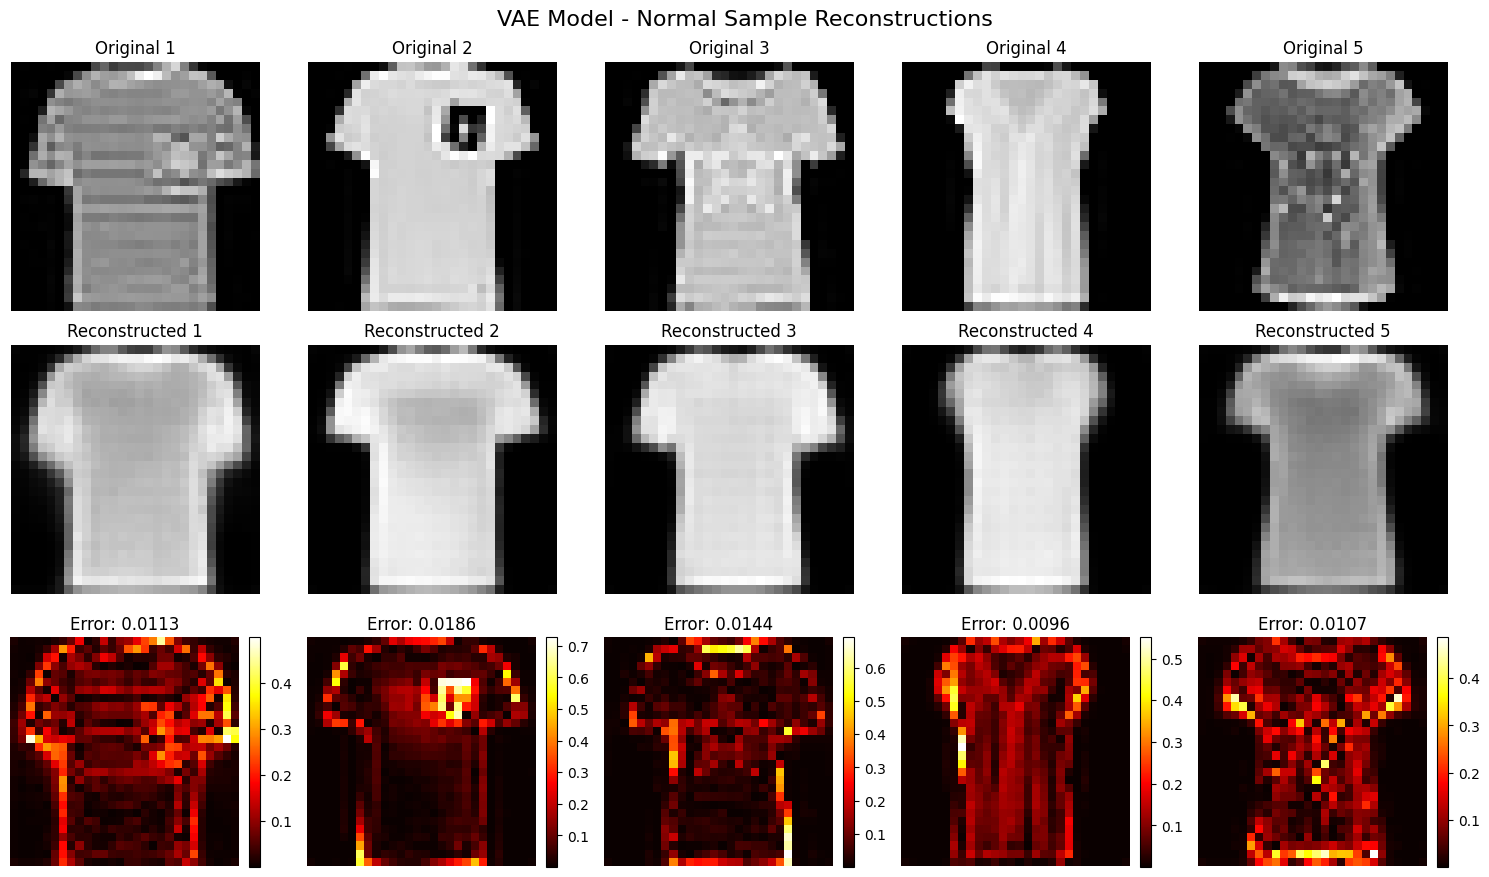


VAE Reconstructions - Anomalous Samples:


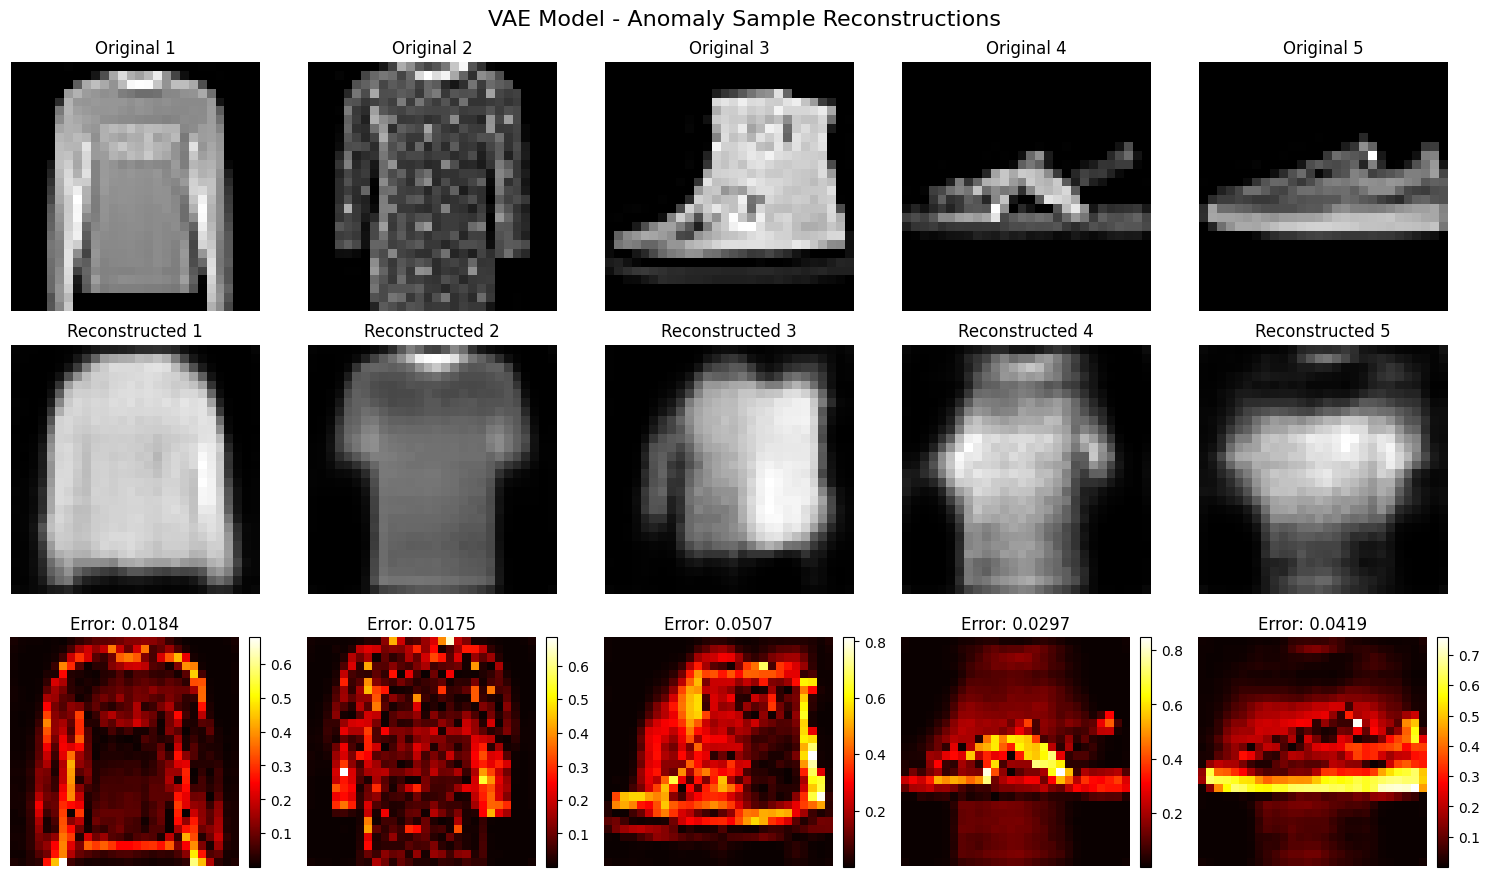

In [ ]:
# ============================================================================
# Cell 37: Visualize VAE Reconstructions
# ============================================================================
"""
Visualize VAE reconstructions for normal and anomalous samples
"""

print("\nVAE Reconstructions - Normal Samples:")
visualize_reconstructions(x_test, vae_reconstructions, vae_errors,
                         y_test, sample_type='normal', n_samples=5,
                         model_name='VAE Model')

print("\nVAE Reconstructions - Anomalous Samples:")
visualize_reconstructions(x_test, vae_reconstructions, vae_errors,
                         y_test, sample_type='anomaly', n_samples=5,
                         model_name='VAE Model')


FINAL PERFORMANCE COMPARISON - ALL MODELS
           Baseline  Improved       VAE
Accuracy   0.759900  0.699800  0.826900
Precision  0.949952  0.954945  0.974045
Recall     0.774000  0.699444  0.829778
F1-Score   0.852997  0.807465  0.896142
ROC-AUC    0.737625  0.761591  0.892737


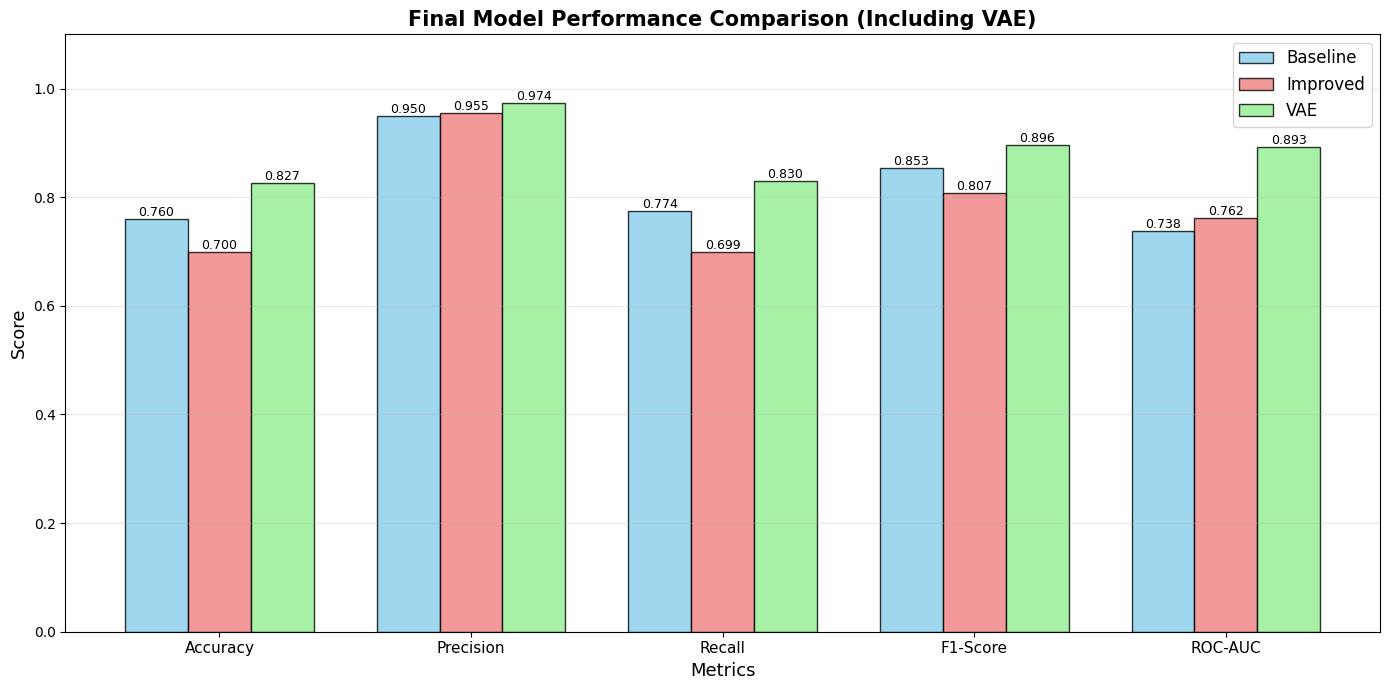


🏆 Best performing model (ROC-AUC): VAE

✓ VAE implementation and evaluation completed successfully!
✓ Ready to proceed with Attention Blocks extension


In [ ]:
# ============================================================================
# Cell 38: Comprehensive Performance Comparison Table
# ============================================================================
"""
Create final comparison table including VAE
"""

# Compute VAE metrics
vae_metrics = {
    'Accuracy': accuracy_score(y_test, vae_predictions),
    'Precision': precision_score(y_test, vae_predictions),
    'Recall': recall_score(y_test, vae_predictions),
    'F1-Score': f1_score(y_test, vae_predictions),
    'ROC-AUC': vae_auc,
    'Average Precision': vae_ap,
    'Threshold': vae_threshold
}

# Create comprehensive comparison
final_comparison = pd.DataFrame({
    'Baseline': [baseline_metrics[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']],
    'Improved': [improved_metrics[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']],
    'VAE': [vae_metrics[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])

print("\n" + "="*80)
print("FINAL PERFORMANCE COMPARISON - ALL MODELS")
print("="*80)
print(final_comparison.to_string())
print("="*80)

# Visualize final comparison
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
baseline_vals = final_comparison['Baseline'].values
improved_vals = final_comparison['Improved'].values
vae_vals = final_comparison['VAE'].values

x = np.arange(len(metrics_list))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width, baseline_vals, width, label='Baseline',
               alpha=0.8, color='skyblue', edgecolor='black')
bars2 = ax.bar(x, improved_vals, width, label='Improved',
               alpha=0.8, color='lightcoral', edgecolor='black')
bars3 = ax.bar(x + width, vae_vals, width, label='VAE',
               alpha=0.8, color='lightgreen', edgecolor='black')

ax.set_xlabel('Metrics', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Final Model Performance Comparison (Including VAE)',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Determine best model
best_model_auc = max(baseline_auc, improved_auc, vae_auc)
if best_model_auc == vae_auc:
    best = "VAE"
elif best_model_auc == improved_auc:
    best = "Improved"
else:
    best = "Baseline"

print(f"\n🏆 Best performing model (ROC-AUC): {best}")
print("\n✓ VAE implementation and evaluation completed successfully!")
print("✓ Ready to proceed with Attention Blocks extension")

# BONUS EXTENSION 2: ATTENTION MECHANISM
# Add self-attention blocks to improve feature learning

In [ ]:
# ============================================================================
# Cell 39: Understanding Attention in Autoencoders
# ============================================================================
"""
ATTENTION MECHANISM - Why it helps:

Standard CNN:
- Treats all spatial locations equally
- Fixed receptive field

Self-Attention:
- Learns to focus on important regions
- Global context awareness
- Better reconstruction of fine details

Benefits for Anomaly Detection:
1. Focus on discriminative features
2. Better capture of spatial dependencies
3. Improved reconstruction quality
4. More accurate anomaly localization
"""

print("Implementing Attention-Enhanced Convolutional Autoencoder")
print("="*60)

Implementing Attention-Enhanced Convolutional Autoencoder


In [ ]:
# ============================================================================
# Cell 40: Self-Attention Layer Implementation
# ============================================================================
"""
Implement Self-Attention layer for spatial feature enhancement
Based on Self-Attention GAN (SAGAN) architecture
"""

class SelfAttention(layers.Layer):
    """
    Self-Attention Layer
    Computes attention weights across spatial locations
    """
    def __init__(self, channels, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)
        self.channels = channels

    def build(self, input_shape):
        # Query, Key, Value transformations
        self.query_conv = layers.Conv2D(self.channels // 8, 1, padding='same')
        self.key_conv = layers.Conv2D(self.channels // 8, 1, padding='same')
        self.value_conv = layers.Conv2D(self.channels, 1, padding='same')

        # Output projection
        self.output_conv = layers.Conv2D(self.channels, 1, padding='same')

        # Learnable scale parameter
        self.gamma = self.add_weight(
            name='gamma',
            shape=(1,),
            initializer='zeros',
            trainable=True
        )

        super(SelfAttention, self).build(input_shape)

    def call(self, x):
        batch_size, height, width, channels = tf.shape(x)[0], x.shape[1], x.shape[2], x.shape[3]

        # Generate query, key, value
        query = self.query_conv(x)  # [B, H, W, C//8]
        key = self.key_conv(x)      # [B, H, W, C//8]
        value = self.value_conv(x)  # [B, H, W, C]

        # Reshape for matrix multiplication
        query = tf.reshape(query, [batch_size, height * width, -1])  # [B, N, C//8]
        key = tf.reshape(key, [batch_size, height * width, -1])      # [B, N, C//8]
        value = tf.reshape(value, [batch_size, height * width, -1])  # [B, N, C]

        # Compute attention weights
        # attention = softmax(query * key^T)
        attention = tf.nn.softmax(
            tf.matmul(query, key, transpose_b=True),  # [B, N, N]
            axis=-1
        )

        # Apply attention to values
        out = tf.matmul(attention, value)  # [B, N, C]

        # Reshape back to spatial dimensions
        out = tf.reshape(out, [batch_size, height, width, channels])

        # Apply output projection
        out = self.output_conv(out)

        # Residual connection with learnable weight
        out = self.gamma * out + x

        return out

    def get_config(self):
        config = super(SelfAttention, self).get_config()
        config.update({'channels': self.channels})
        return config

print("✓ Self-Attention layer implemented")


✓ Self-Attention layer implemented


In [ ]:
# ============================================================================
# Cell 41: Build Attention-Enhanced CAE
# ============================================================================
"""
Build improved CAE with Self-Attention blocks
Attention is added after middle convolutional layers
"""

def build_attention_cae(input_shape=(28, 28, 1)):
    """
    Build CAE with Self-Attention mechanism

    Args:
        input_shape: Shape of input images

    Returns:
        model: Keras Model with attention
    """

    # ========== ENCODER ==========
    encoder_input = layers.Input(shape=input_shape, name='attention_encoder_input')

    # First encoder block
    x = layers.Conv2D(32, (3, 3), padding='same', name='att_enc_conv1')(encoder_input)
    x = layers.BatchNormalization(name='att_enc_bn1')(x)
    x = layers.LeakyReLU(alpha=0.2, name='att_enc_activation1')(x)
    skip1 = x
    x = layers.MaxPooling2D((2, 2), padding='same', name='att_enc_pool1')(x)
    x = layers.Dropout(0.25, name='att_enc_dropout1')(x)

    # Second encoder block with ATTENTION
    x = layers.Conv2D(64, (3, 3), padding='same', name='att_enc_conv2')(x)
    x = layers.BatchNormalization(name='att_enc_bn2')(x)
    x = layers.LeakyReLU(alpha=0.2, name='att_enc_activation2')(x)
    x = SelfAttention(64, name='encoder_attention')(x)  # ← ATTENTION HERE
    skip2 = x
    x = layers.MaxPooling2D((2, 2), padding='same', name='att_enc_pool2')(x)
    x = layers.Dropout(0.25, name='att_enc_dropout2')(x)

    # Third encoder block (bottleneck)
    x = layers.Conv2D(128, (3, 3), padding='same', name='att_enc_conv3')(x)
    x = layers.BatchNormalization(name='att_enc_bn3')(x)
    encoded = layers.LeakyReLU(alpha=0.2, name='att_enc_activation3')(x)

    # ========== DECODER ==========
    # First decoder block
    x = layers.Conv2DTranspose(128, (3, 3), strides=1, padding='same',
                               name='att_dec_conv1')(encoded)
    x = layers.BatchNormalization(name='att_dec_bn1')(x)
    x = layers.LeakyReLU(alpha=0.2, name='att_dec_activation1')(x)
    x = layers.Dropout(0.25, name='att_dec_dropout1')(x)

    # Second decoder block with ATTENTION and skip connection
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same',
                               name='att_dec_conv2')(x)
    x = layers.BatchNormalization(name='att_dec_bn2')(x)
    x = layers.LeakyReLU(alpha=0.2, name='att_dec_activation2')(x)
    x = SelfAttention(64, name='decoder_attention')(x)  # ← ATTENTION HERE
    x = layers.Concatenate(name='att_skip_connection2')([x, skip2])
    x = layers.Dropout(0.25, name='att_dec_dropout2')(x)

    # Third decoder block with skip connection
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same',
                               name='att_dec_conv3')(x)
    x = layers.BatchNormalization(name='att_dec_bn3')(x)
    x = layers.LeakyReLU(alpha=0.2, name='att_dec_activation3')(x)
    x = layers.Concatenate(name='att_skip_connection1')([x, skip1])

    # Output layer
    decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid',
                                   padding='same', name='att_dec_output')(x)

    # Create model
    autoencoder = models.Model(encoder_input, decoder_output,
                              name='Attention_Enhanced_CAE')

    return autoencoder


# Build attention model
attention_model = build_attention_cae(input_shape=(28, 28, 1))

# Display architecture
attention_model.summary()

print("\n✓ Attention-enhanced CAE built successfully")
print(f"Total parameters: {attention_model.count_params():,}")

Model: "Attention_Enhanced_CAE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ attention_encoder_… │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_conv1       │ (None, 28, 28,    │        320 │ attention_encode… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_bn1         │ (None, 28, 28,    │        128 │ att_enc_conv1[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_activation1 │ (None, 28, 28,    │          0 │ att_enc_bn1[0][0] │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_pool1       │ (None, 14, 14,    │          0 │ att_enc_activati… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_dropout1    │ (None, 14, 14,    │          0 │ att_enc_pool1[0]… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_conv2       │ (None, 14, 14,    │     18,496 │ att_enc_dropout1… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_bn2         │ (None, 14, 14,    │        256 │ att_enc_conv2[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_activation2 │ (None, 14, 14,    │          0 │ att_enc_bn2[0][0] │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_attention   │ (None, 14, 14,    │      9,361 │ att_enc_activati… │
│ (SelfAttention)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_pool2       │ (None, 7, 7, 64)  │          0 │ encoder_attentio… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_dropout2    │ (None, 7, 7, 64)  │          0 │ att_enc_pool2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_conv3       │ (None, 7, 7, 128) │     73,856 │ att_enc_dropout2… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_bn3         │ (None, 7, 7, 128) │        512 │ att_enc_conv3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_enc_activation3 │ (None, 7, 7, 128) │          0 │ att_enc_bn3[0][0] │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_dec_conv1       │ (None, 7, 7, 128) │    147,584 │ att_enc_activati… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_dec_bn1         │ (None, 7, 7, 128) │        512 │ att_dec_conv1[0]

 Total params: 372,035 (1.42 MB)

 Trainable params: 371,139 (1.42 MB)

 Non-trainable params: 896 (3.50 KB)


✓ Attention-enhanced CAE built successfully
Total parameters: 372,035


In [ ]:
# ============================================================================
# Cell 42: Compile and Train Attention Model
# ============================================================================
"""
Compile and train the attention-enhanced model
"""

# Compile
attention_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mse', 'mae']
)

# Setup callbacks
callbacks_attention = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'attention_cae_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train the model
print("Starting training of Attention-enhanced model...")
print(f"Training on {len(x_train)} samples")
print(f"Validating on {len(x_val)} samples")

attention_history = attention_model.fit(
    x_train, x_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, x_val),
    callbacks=callbacks_attention,
    verbose=1
)

print("\n✓ Attention model training completed!")

Starting training of Attention-enhanced model...
Training on 4800 samples
Validating on 1200 samples
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - loss: 0.0875 - mae: 0.2045 - mse: 0.0875
Epoch 1: val_loss improved from inf to 0.09871, saving model to attention_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 511ms/step - loss: 0.0862 - mae: 0.2023 - mse: 0.0862 - val_loss: 0.0987 - val_mae: 0.2894 - val_mse: 0.0987 - learning_rate: 0.0010
Epoch 2/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0050 - mae: 0.0470 - mse: 0.0050
Epoch 2: val_loss improved from 0.09871 to 0.08738, saving model to attention_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.0050 - mae: 0.0468 - mse: 0.0050 - val_loss: 0.0874 - val_mae: 0.2734 - val_mse: 0.0874 - learning_rate: 0.0010
Epoch 3/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0026 - mae: 0.0355 - mse: 0.0026
Epoch 3: val_loss improved from 0.08738 to 0.07465, saving model to attention_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0026 - mae: 0.0354 - mse: 0.0026 - val_loss: 0.0746 - val_mae: 0.2518 - val_mse: 0.0746 - learning_rate: 0.0010
Epoch 4/50
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0018 - mae: 0.0302 - mse: 0.0018
Epoch 4: val_loss improved from 0.07465 to 0.06572, saving model to attention_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0018 - mae: 0.0301 - mse: 0.0018 - val_loss: 0.0657 - val_mae: 0.2340 - val_mse: 0.0657 - learning_rate: 0.0010
Epoch 5/50
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0015 - mae: 0.0272 - mse: 0.0015
Epoch 5: val_loss improved from 0.06572 to 0.05755, saving model to attention_cae_best.h5


...

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 5.5994e-04 - mae: 0.0163 - mse: 5.5994e-04 - val_loss: 5.2563e-04 - val_mae: 0.0154 - val_mse: 5.2563e-04 - learning_rate: 5.0000e-04
Epoch 36/50
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.5954e-04 - mae: 0.0162 - mse: 5.5954e-04
Epoch 36: val_loss improved from 0.00053 to 0.00051, saving model to attention_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 5.5858e-04 - mae: 0.0162 - mse: 5.5858e-04 - val_loss: 5.0556e-04 - val_mae: 0.0150 - val_mse: 5.0556e-04 - learning_rate: 5.0000e-04
Epoch 37/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 5.5633e-04 - mae: 0.0162 - mse: 5.5633e-04
Epoch 37: val_loss improved from 0.00051 to 0.00050, saving model to attention_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 5.5570e-04 - mae: 0.0162 - mse: 5.5570e-04 - val_loss: 4.9727e-04 - val_mae: 0.0149 - val_mse: 4.9727e-04 - learning_rate: 5.0000e-04
Epoch 38/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 5.5293e-04 - mae: 0.0161 - mse: 5.5293e-04
Epoch 38: val_loss improved from 0.00050 to 0.00049, saving model to attention_cae_best.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 5.5235e-04 - mae: 0.0161 - mse: 5.5235e-04 - val_loss: 4.8883e-04 - val_mae: 0.0147 - val_mse: 4.8883e-04 - learning_rate: 5.0000e-04
Epoch 39/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.4835e-04 - mae: 0.0160 - mse: 5.4835e-04
Epoch 39: val_loss improved from 0.00049 to 0.00048, saving model to attention_cae_best.h5



Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 5.4810e-04 - mae: 0.0160 - mse: 5.4810e-04 - val_loss: 4.8073e-04 - val_mae: 0.0146 - val_mse: 4.8073e-04 - learning_rate: 5.0000e-04
Epoch 40/50
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.2011e-04 - mae: 0.0155 - mse: 5.2011e-04
Epoch 40: val_loss did not improve from 0.00048
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.1918e-04 - mae: 0.0155 - mse: 5.1918e-04 - val_loss: 5.2796e-04 - val_mae: 0.0156 - val_mse: 5.2796e-04 - learning_rate: 2.5000e-04
Epoch 41/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.1869e-04 - mae: 0.0156 - mse: 5.1869e-04
Epoch 41: val_loss did not improve from 0.00048
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.1783e-04 - mae: 0.0155 - mse: 5.1783e-04 - val_loss: 5.2212e-04 - val_mae: 0.0155 - val_mse: 5.2212e-04 - learning_rate: 2.5000e-04
Epoch 42/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.1478e-04 - m

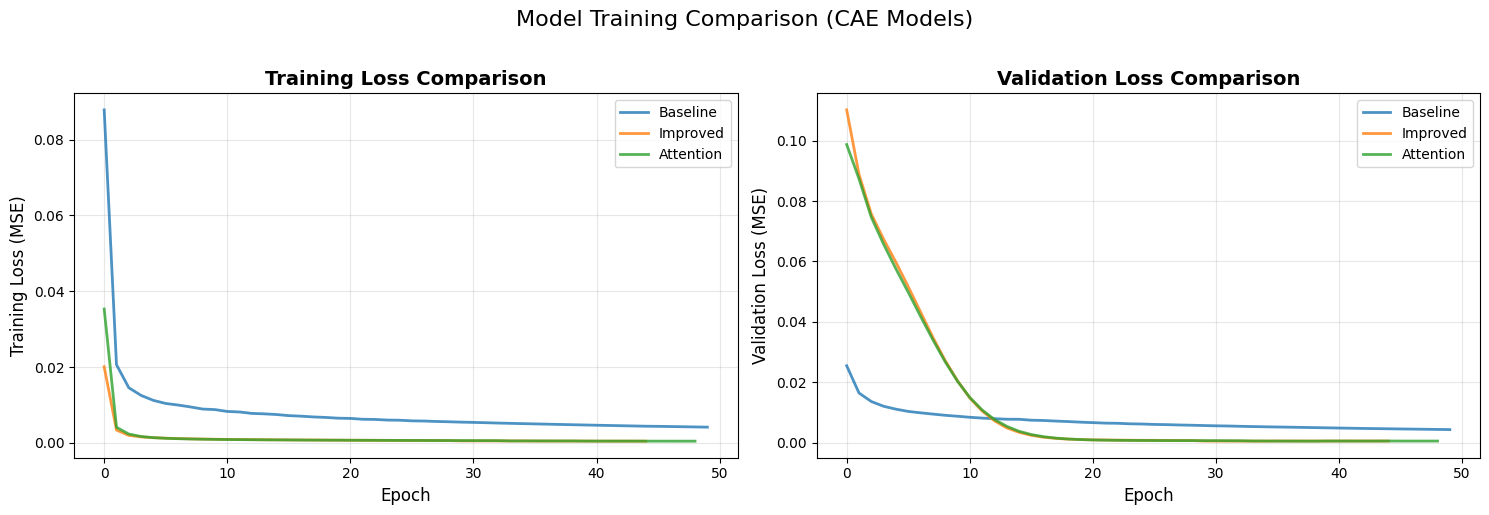


FINAL TRAINING METRICS COMPARISON
Model                Train Loss      Val Loss       
------------------------------------------------------------
Baseline             0.004178          0.004311
Improved             0.000482          0.000524
Attention            0.000483          0.000519


In [ ]:
# ============================================================================
# Cell 43: Compare Training Histories - All Models
# ============================================================================
"""
Compare training curves for all four models:
Baseline, Improved, VAE, and Attention-enhanced
"""

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training loss
axes[0].plot(baseline_history.history['loss'], label='Baseline', linewidth=2, alpha=0.8)
axes[0].plot(improved_history.history['loss'], label='Improved', linewidth=2, alpha=0.8)
axes[0].plot(attention_history.history['loss'], label='Attention', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss (MSE)', fontsize=12)
axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation loss
axes[1].plot(baseline_history.history['val_loss'], label='Baseline', linewidth=2, alpha=0.8)
axes[1].plot(improved_history.history['val_loss'], label='Improved', linewidth=2, alpha=0.8)
axes[1].plot(attention_history.history['val_loss'], label='Attention', linewidth=2, alpha=0.8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss (MSE)', fontsize=12)
axes[1].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Training Comparison (CAE Models)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL TRAINING METRICS COMPARISON")
print("="*60)
print(f"{'Model':<20} {'Train Loss':<15} {'Val Loss':<15}")
print("-"*60)
print(f"{'Baseline':<20} {baseline_history.history['loss'][-1]:.6f}{'':>9} "
      f"{baseline_history.history['val_loss'][-1]:.6f}")
print(f"{'Improved':<20} {improved_history.history['loss'][-1]:.6f}{'':>9} "
      f"{improved_history.history['val_loss'][-1]:.6f}")
print(f"{'Attention':<20} {attention_history.history['loss'][-1]:.6f}{'':>9} "
      f"{attention_history.history['val_loss'][-1]:.6f}")
print("="*60)


Evaluating Attention-enhanced model...
Attention model - Error range: [0.000142, 0.004350]
Optimal threshold: 0.000405

ATTENTION MODEL - ANOMALY DETECTION PERFORMANCE
Threshold: 0.000405

              precision    recall  f1-score   support

      Normal     0.2340    0.5780    0.3331      1000
     Anomaly     0.9440    0.7898    0.8600      9000

    accuracy                         0.7686     10000
   macro avg     0.5890    0.6839    0.5966     10000
weighted avg     0.8730    0.7686    0.8073     10000



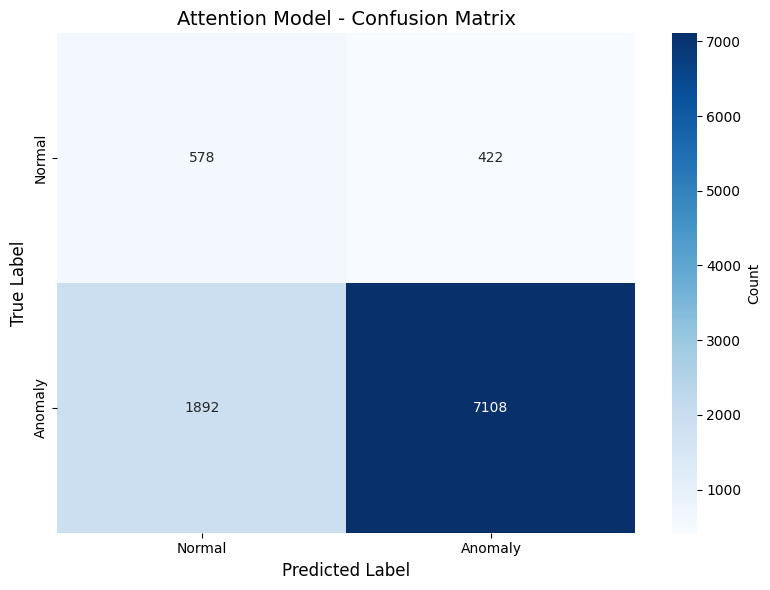


ROC-AUC Score: 0.7266
Average Precision: 0.9471


In [ ]:
# ============================================================================
# Cell 44: Evaluate Attention Model on Test Set
# ============================================================================
"""
Compute reconstruction errors and evaluate anomaly detection
for the attention-enhanced model
"""

print("Evaluating Attention-enhanced model...")

# Compute reconstruction errors
attention_errors, attention_reconstructions = compute_reconstruction_error(
    attention_model, x_test
)

print(f"Attention model - Error range: [{attention_errors.min():.6f}, {attention_errors.max():.6f}]")

# Find optimal threshold
attention_threshold = find_optimal_threshold(y_test, attention_errors)
print(f"Optimal threshold: {attention_threshold:.6f}")

# Make predictions
attention_predictions = (attention_errors > attention_threshold).astype(int)

# Evaluate performance
print("\n" + "="*60)
print("ATTENTION MODEL - ANOMALY DETECTION PERFORMANCE")
print("="*60)
print(f"Threshold: {attention_threshold:.6f}\n")
print(classification_report(y_test, attention_predictions,
                           target_names=['Normal', 'Anomaly'],
                           digits=4))

# Confusion matrix
cm_attention = confusion_matrix(y_test, attention_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_attention, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Attention Model - Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Compute ROC metrics
attention_fpr, attention_tpr, _ = roc_curve(y_test, attention_errors)
attention_auc = roc_auc_score(y_test, attention_errors)
attention_precision, attention_recall, _ = precision_recall_curve(y_test, attention_errors)
attention_ap = average_precision_score(y_test, attention_errors)

print(f"\nROC-AUC Score: {attention_auc:.4f}")
print(f"Average Precision: {attention_ap:.4f}")

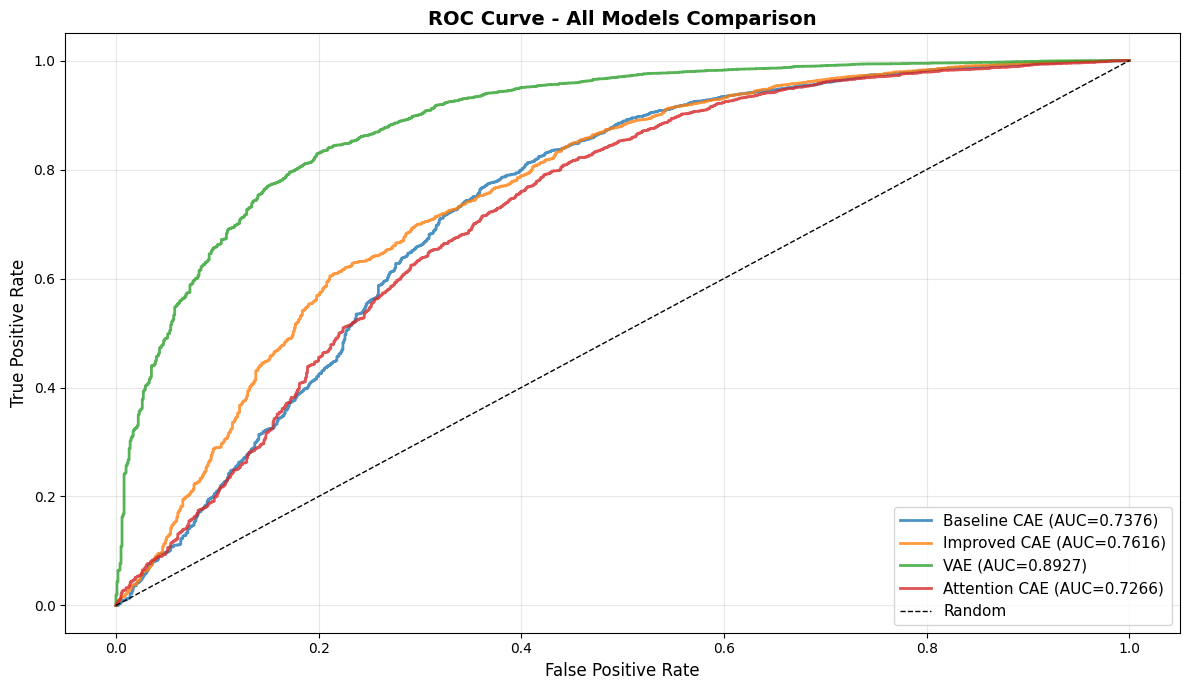

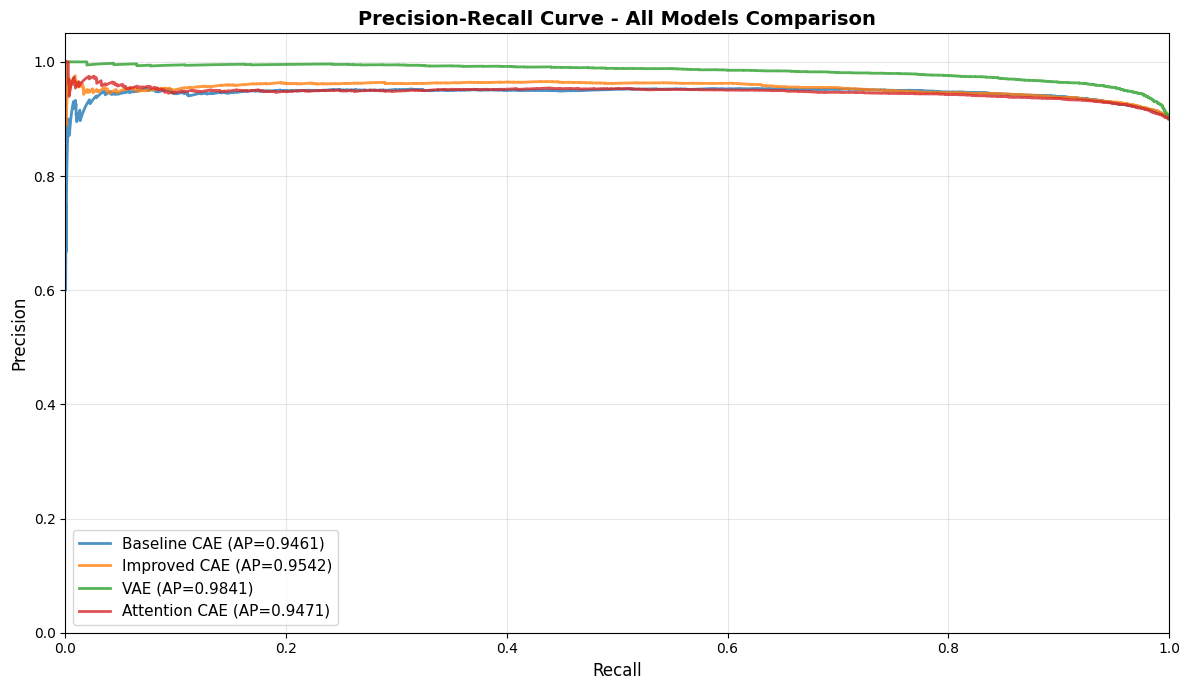


COMPREHENSIVE PERFORMANCE COMPARISON - ALL MODELS
           Baseline  Improved       VAE  Attention
Accuracy   0.759900  0.699800  0.826900   0.768600
Precision  0.949952  0.954945  0.974045   0.943958
Recall     0.774000  0.699444  0.829778   0.789778
F1-Score   0.852997  0.807465  0.896142   0.860012
ROC-AUC    0.737625  0.761591  0.892737   0.726587


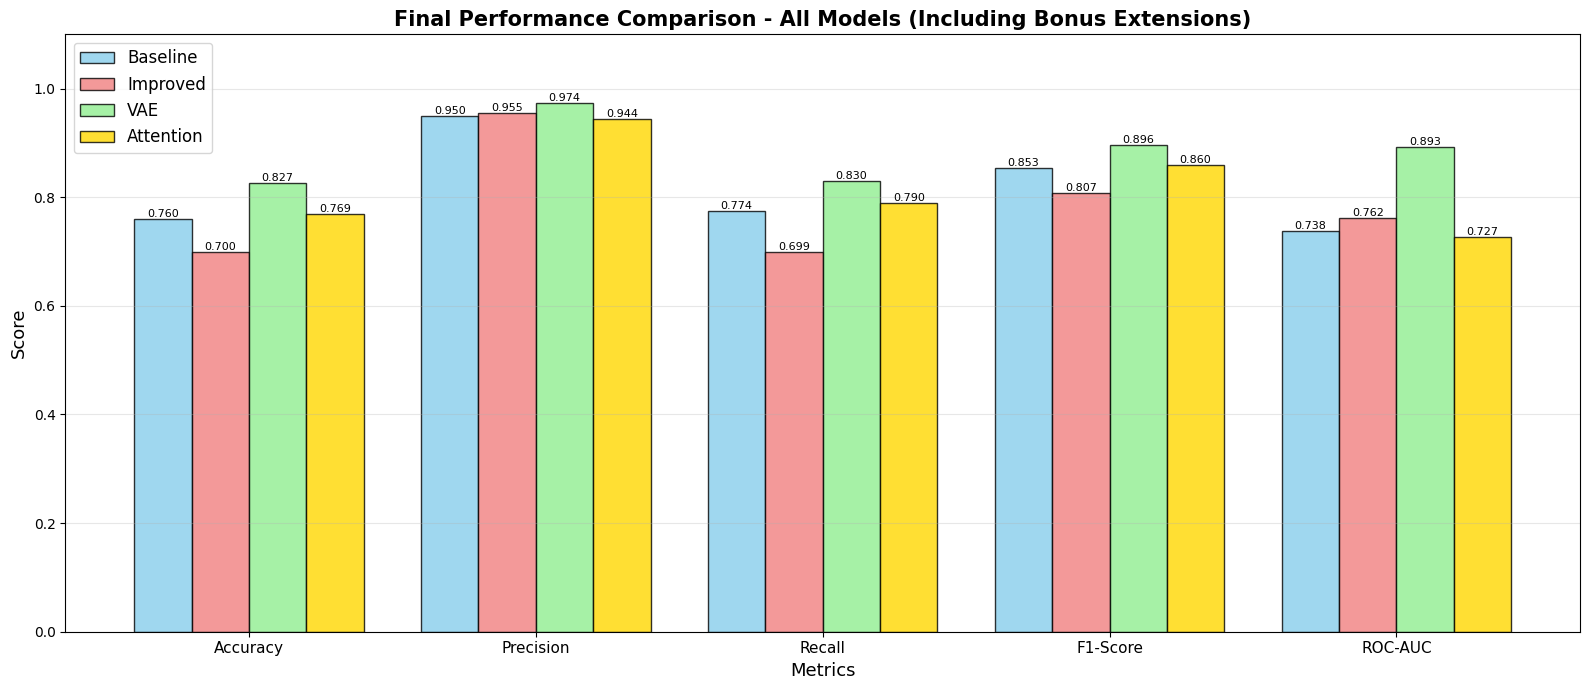


BEST MODEL FOR EACH METRIC
Accuracy            : VAE             (Score: 0.8269)
Precision           : VAE             (Score: 0.9740)
Recall              : VAE             (Score: 0.8298)
F1-Score            : VAE             (Score: 0.8961)
ROC-AUC             : VAE             (Score: 0.8927)


In [ ]:
# ============================================================================
# Cell 45: Comprehensive Comparison - All Four Models
# ============================================================================
"""
Final comparison including all models:
1. Baseline CAE
2. Improved CAE
3. VAE
4. Attention-enhanced CAE
"""

# Plot ROC curves for all models
plt.figure(figsize=(12, 7))
plt.plot(baseline_fpr, baseline_tpr, linewidth=2,
        label=f'Baseline CAE (AUC={baseline_auc:.4f})', alpha=0.8)
plt.plot(improved_fpr, improved_tpr, linewidth=2,
        label=f'Improved CAE (AUC={improved_auc:.4f})', alpha=0.8)
plt.plot(vae_fpr, vae_tpr, linewidth=2,
        label=f'VAE (AUC={vae_auc:.4f})', alpha=0.8)
plt.plot(attention_fpr, attention_tpr, linewidth=2,
        label=f'Attention CAE (AUC={attention_auc:.4f})', alpha=0.8)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - All Models Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curves
plt.figure(figsize=(12, 7))
plt.plot(baseline_recall, baseline_precision, linewidth=2,
        label=f'Baseline CAE (AP={baseline_ap:.4f})', alpha=0.8)
plt.plot(improved_recall, improved_precision, linewidth=2,
        label=f'Improved CAE (AP={improved_ap:.4f})', alpha=0.8)
plt.plot(vae_recall, vae_precision, linewidth=2,
        label=f'VAE (AP={vae_ap:.4f})', alpha=0.8)
plt.plot(attention_recall, attention_precision, linewidth=2,
        label=f'Attention CAE (AP={attention_ap:.4f})', alpha=0.8)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - All Models Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower left')
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

# Compute metrics for attention model
attention_metrics = {
    'Accuracy': accuracy_score(y_test, attention_predictions),
    'Precision': precision_score(y_test, attention_predictions),
    'Recall': recall_score(y_test, attention_predictions),
    'F1-Score': f1_score(y_test, attention_predictions),
    'ROC-AUC': attention_auc,
    'Average Precision': attention_ap
}

# Create comprehensive comparison table
all_models_comparison = pd.DataFrame({
    'Baseline': [baseline_metrics[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']],
    'Improved': [improved_metrics[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']],
    'VAE': [vae_metrics[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']],
    'Attention': [attention_metrics[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])

print("\n" + "="*90)
print("COMPREHENSIVE PERFORMANCE COMPARISON - ALL MODELS")
print("="*90)
print(all_models_comparison.to_string())
print("="*90)

# Visualize comparison
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
baseline_vals = all_models_comparison['Baseline'].values
improved_vals = all_models_comparison['Improved'].values
vae_vals = all_models_comparison['VAE'].values
attention_vals = all_models_comparison['Attention'].values

x = np.arange(len(metrics_list))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - 1.5*width, baseline_vals, width, label='Baseline',
               alpha=0.8, color='skyblue', edgecolor='black')
bars2 = ax.bar(x - 0.5*width, improved_vals, width, label='Improved',
               alpha=0.8, color='lightcoral', edgecolor='black')
bars3 = ax.bar(x + 0.5*width, vae_vals, width, label='VAE',
               alpha=0.8, color='lightgreen', edgecolor='black')
bars4 = ax.bar(x + 1.5*width, attention_vals, width, label='Attention',
               alpha=0.8, color='gold', edgecolor='black')

ax.set_xlabel('Metrics', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Final Performance Comparison - All Models (Including Bonus Extensions)',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

# Add value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Find best model for each metric
print("\n" + "="*90)
print("BEST MODEL FOR EACH METRIC")
print("="*90)
for metric in metrics_list:
    best_model = all_models_comparison.loc[metric].idxmax()
    best_score = all_models_comparison.loc[metric].max()
    print(f"{metric:<20}: {best_model:<15} (Score: {best_score:.4f})")
print("="*90)


Visualizing Attention Model Reconstructions...

Attention Model - Normal Samples:


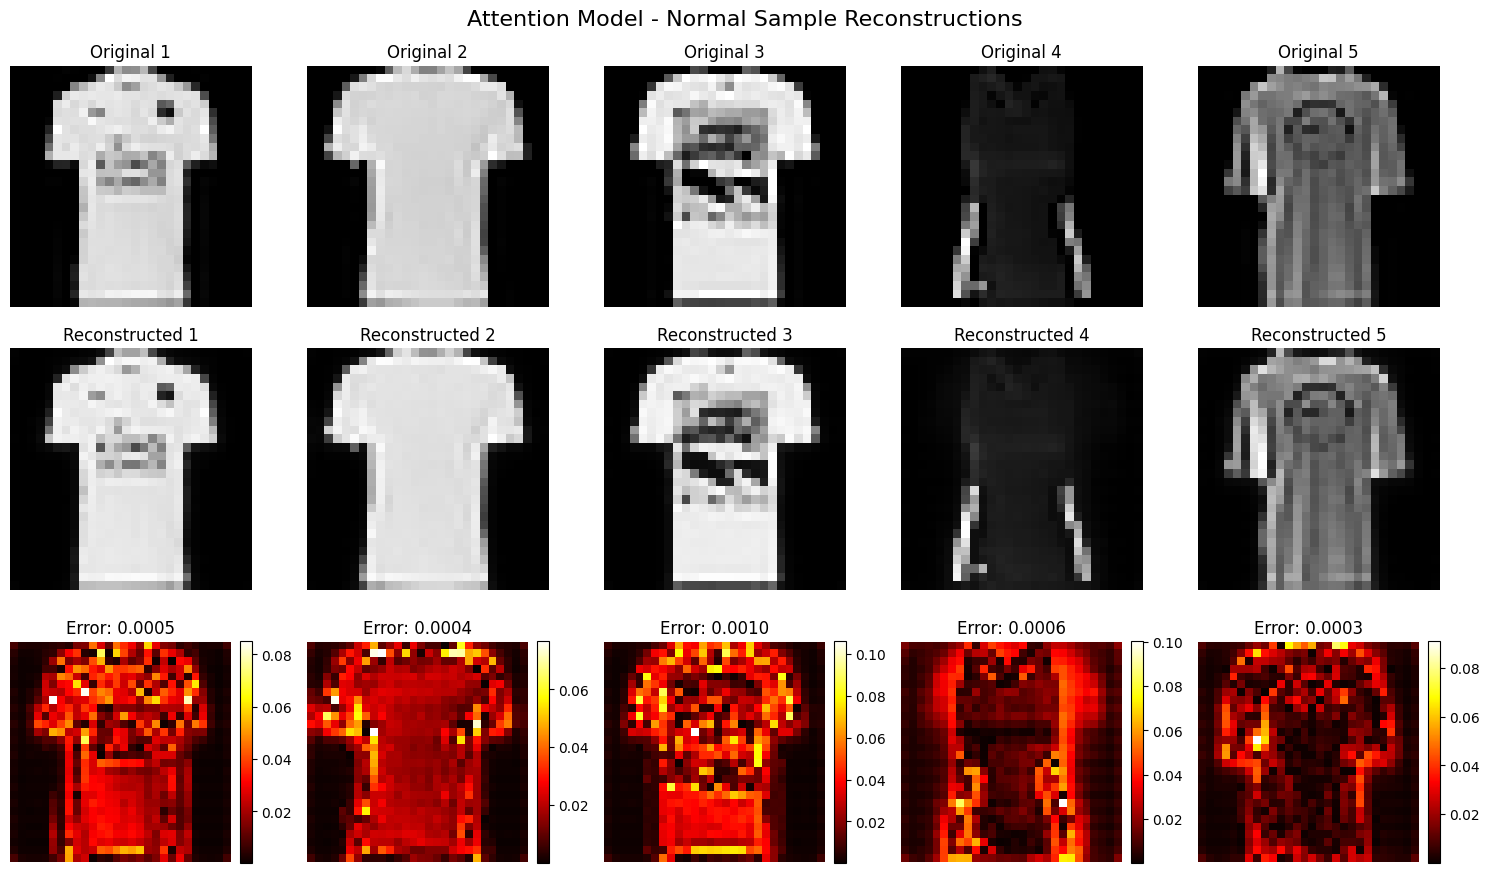


Attention Model - Anomalous Samples:


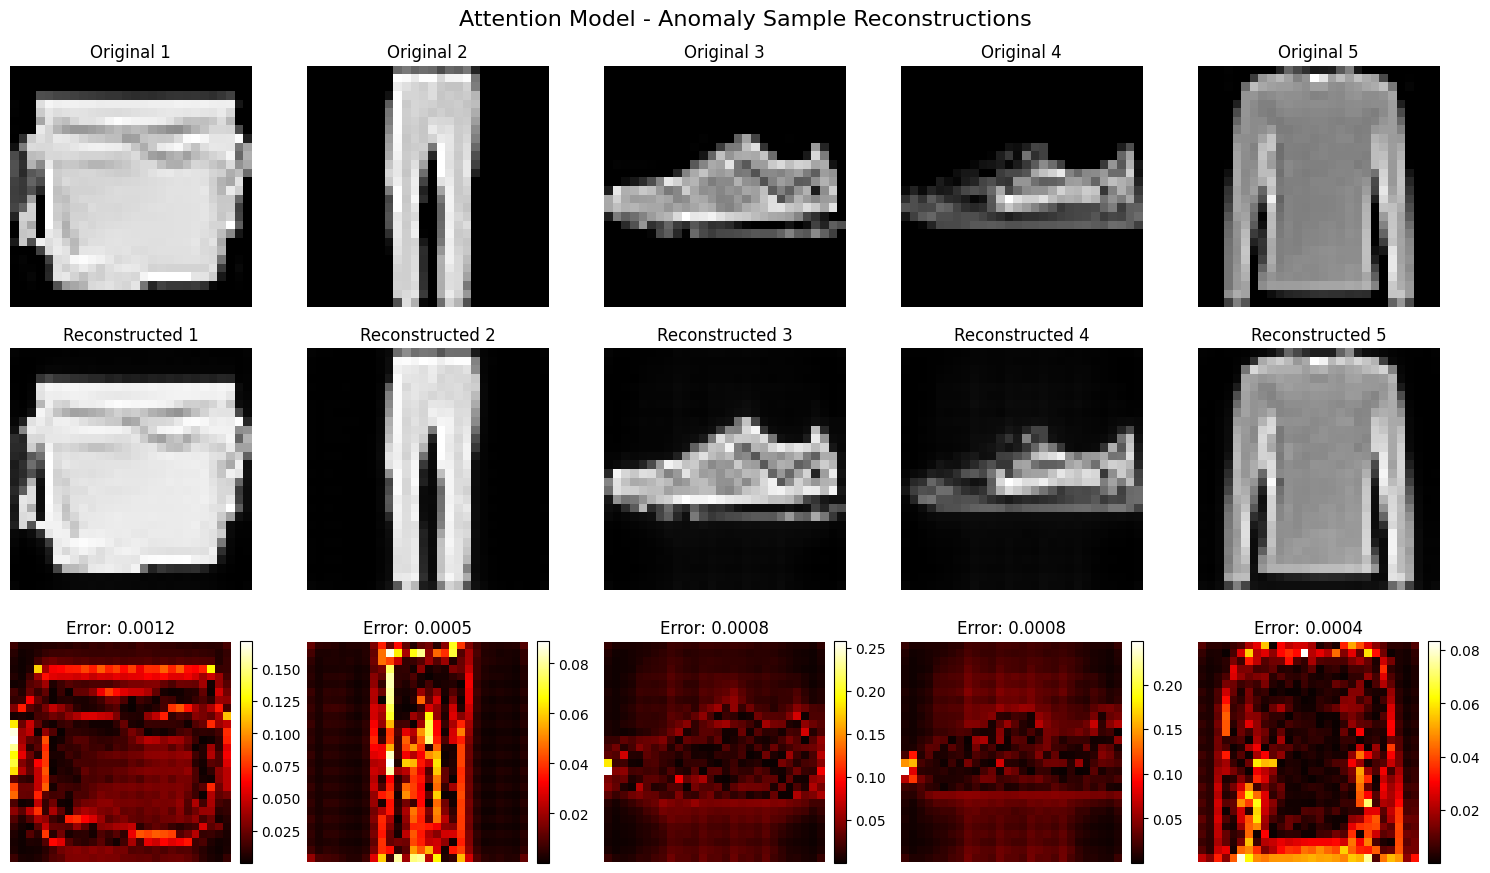


Comparing All Models on Same Samples...


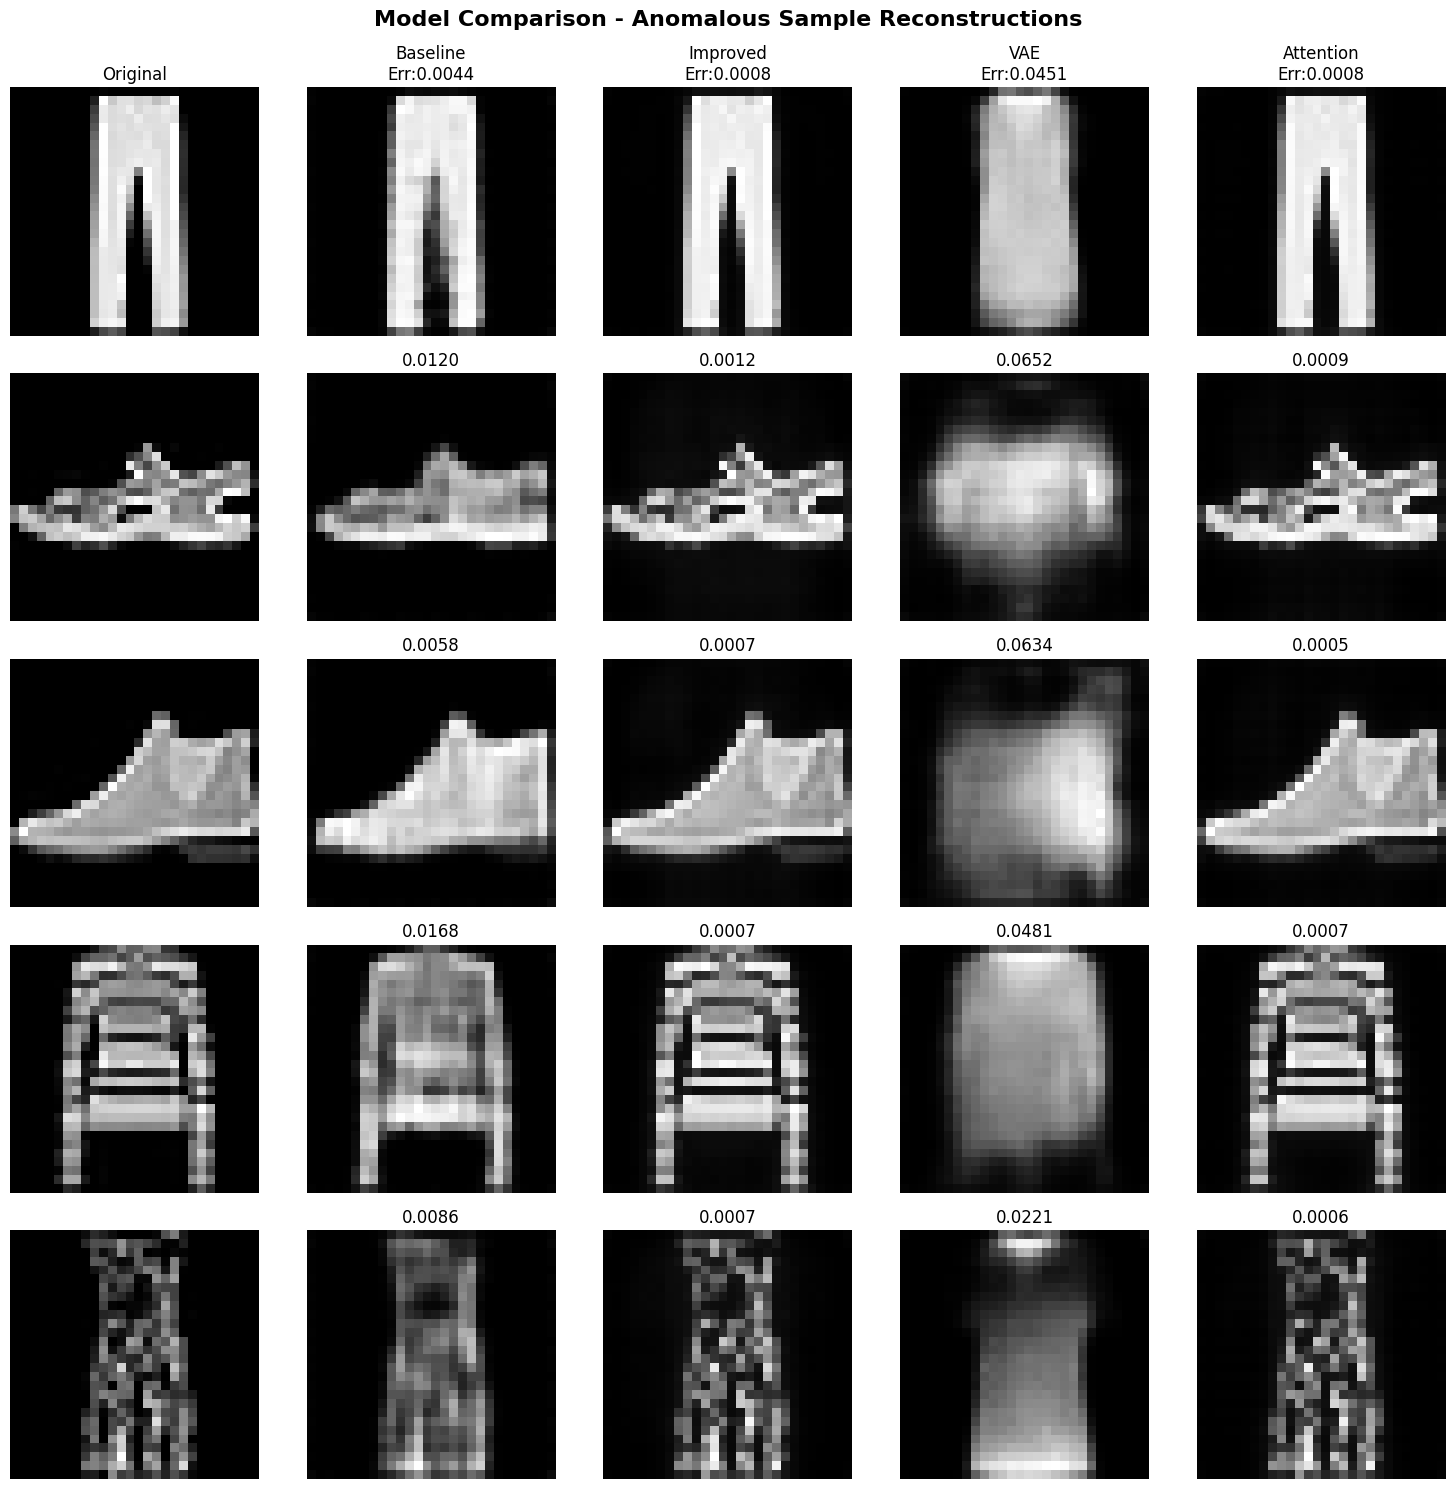


RECONSTRUCTION ERROR STATISTICS - ALL MODELS
Model           Normal Mean     Anomaly Mean    Separation      Ratio     
------------------------------------------------------------------------------------------
Baseline        0.004025        0.006075        0.002049        1.51      
Improved        0.000477        0.000746        0.000270        1.57      
VAE             0.015978        0.039399        0.023421        2.47      
Attention       0.000471        0.000681        0.000210        1.45      

✓ Attention mechanism implementation completed!
✓ All bonus extensions finished!

PROJECT SUMMARY
✓ Baseline CAE - Implemented and evaluated
✓ Improved CAE - Added BatchNorm, Dropout, Skip Connections
✓ VAE (BONUS 1) - Variational approach with probabilistic encoding
✓ Attention CAE (BONUS 2) - Self-attention for better feature learning

Total Models: 4
Bonus Extensions Completed: 2/4 (VAE + Attention)


In [ ]:
# ============================================================================
# Cell 46: Visualize Attention Model Reconstructions
# ============================================================================
"""
Visualize reconstructions from attention model
and compare with other models
"""

print("\nVisualizing Attention Model Reconstructions...")

# Normal samples
print("\nAttention Model - Normal Samples:")
visualize_reconstructions(x_test, attention_reconstructions, attention_errors,
                         y_test, sample_type='normal', n_samples=5,
                         model_name='Attention Model')

# Anomalous samples
print("\nAttention Model - Anomalous Samples:")
visualize_reconstructions(x_test, attention_reconstructions, attention_errors,
                         y_test, sample_type='anomaly', n_samples=5,
                         model_name='Attention Model')

# Side-by-side comparison of all models on same samples
print("\nComparing All Models on Same Samples...")

# Select 5 random anomalous samples
anomaly_indices = np.where(y_test == 1)[0]
selected_samples = np.random.choice(anomaly_indices, 5, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for i, idx in enumerate(selected_samples):
    # Original
    axes[i, 0].imshow(x_test[idx].squeeze(), cmap='gray')
    axes[i, 0].set_title('Original' if i == 0 else '')
    axes[i, 0].axis('off')

    # Baseline reconstruction
    axes[i, 1].imshow(baseline_reconstructions[idx].squeeze(), cmap='gray')
    if i == 0:
        axes[i, 1].set_title(f'Baseline\nErr:{baseline_errors[idx]:.4f}')
    else:
        axes[i, 1].set_title(f'{baseline_errors[idx]:.4f}')
    axes[i, 1].axis('off')

    # Improved reconstruction
    axes[i, 2].imshow(improved_reconstructions[idx].squeeze(), cmap='gray')
    if i == 0:
        axes[i, 2].set_title(f'Improved\nErr:{improved_errors[idx]:.4f}')
    else:
        axes[i, 2].set_title(f'{improved_errors[idx]:.4f}')
    axes[i, 2].axis('off')

    # VAE reconstruction
    axes[i, 3].imshow(vae_reconstructions[idx].squeeze(), cmap='gray')
    if i == 0:
        axes[i, 3].set_title(f'VAE\nErr:{vae_errors[idx]:.4f}')
    else:
        axes[i, 3].set_title(f'{vae_errors[idx]:.4f}')
    axes[i, 3].axis('off')

    # Attention reconstruction
    axes[i, 4].imshow(attention_reconstructions[idx].squeeze(), cmap='gray')
    if i == 0:
        axes[i, 4].set_title(f'Attention\nErr:{attention_errors[idx]:.4f}')
    else:
        axes[i, 4].set_title(f'{attention_errors[idx]:.4f}')
    axes[i, 4].axis('off')

plt.suptitle('Model Comparison - Anomalous Sample Reconstructions',
             fontsize=16, y=0.99, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*90)
print("RECONSTRUCTION ERROR STATISTICS - ALL MODELS")
print("="*90)
print(f"{'Model':<15} {'Normal Mean':<15} {'Anomaly Mean':<15} {'Separation':<15} {'Ratio':<10}")
print("-"*90)

models_data = [
    ('Baseline', baseline_errors),
    ('Improved', improved_errors),
    ('VAE', vae_errors),
    ('Attention', attention_errors)
]

for model_name, errors in models_data:
    normal_err = errors[y_test == 0].mean()
    anomaly_err = errors[y_test == 1].mean()
    separation = anomaly_err - normal_err
    ratio = anomaly_err / normal_err if normal_err > 0 else 0

    print(f"{model_name:<15} {normal_err:<15.6f} {anomaly_err:<15.6f} "
          f"{separation:<15.6f} {ratio:<10.2f}")

print("="*90)

print("\n✓ Attention mechanism implementation completed!")
print("✓ All bonus extensions finished!")
print("\n" + "="*90)
print("PROJECT SUMMARY")
print("="*90)
print("✓ Baseline CAE - Implemented and evaluated")
print("✓ Improved CAE - Added BatchNorm, Dropout, Skip Connections")
print("✓ VAE (BONUS 1) - Variational approach with probabilistic encoding")
print("✓ Attention CAE (BONUS 2) - Self-attention for better feature learning")
print("\nTotal Models: 4")
print("Bonus Extensions Completed: 2/4 (VAE + Attention)")
print("="*90)

BONUS EXTENSION 3: WEB APPLICATION DEPLOYMENT 🌐

In [ ]:
# ============================================================================
# Cell 47: Save All Models and Thresholds
# ============================================================================
"""
Save trained models and thresholds for web app deployment
"""

print("Saving models for web app deployment...")
print("="*60)

# Save baseline model
baseline_model.save('baseline_cae_best.h5')
print("✓ Baseline model saved")

# Save improved model
improved_model.save('improved_cae_best.h5')
print("✓ Improved model saved")

# Save attention model (with custom objects)
attention_model.save('attention_cae_best.h5')
print("✓ Attention model saved")

# Save VAE components separately
vae_encoder.save('vae_encoder_best.h5')
vae_decoder.save('vae_decoder_best.h5')
print("✓ VAE encoder and decoder saved")

# Save thresholds and metrics
import json

thresholds = {
    'Baseline': float(baseline_threshold),
    'Improved': float(improved_threshold),
    'VAE': float(vae_threshold),
    'Attention': float(attention_threshold)
}

metrics_summary = {
    'Baseline': {
        'ROC-AUC': float(baseline_auc),
        'Accuracy': float(accuracy_score(y_test, baseline_predictions)),
        'Precision': float(precision_score(y_test, baseline_predictions)),
        'Recall': float(recall_score(y_test, baseline_predictions)),
        'F1-Score': float(f1_score(y_test, baseline_predictions))
    },
    'Improved': {
        'ROC-AUC': float(improved_auc),
        'Accuracy': float(accuracy_score(y_test, improved_predictions)),
        'Precision': float(precision_score(y_test, improved_predictions)),
        'Recall': float(recall_score(y_test, improved_predictions)),
        'F1-Score': float(f1_score(y_test, improved_predictions))
    },
    'VAE': {
        'ROC-AUC': float(vae_auc),
        'Accuracy': float(accuracy_score(y_test, vae_predictions)),
        'Precision': float(precision_score(y_test, vae_predictions)),
        'Recall': float(recall_score(y_test, vae_predictions)),
        'F1-Score': float(f1_score(y_test, vae_predictions))
    },
    'Attention': {
        'ROC-AUC': float(attention_auc),
        'Accuracy': float(accuracy_score(y_test, attention_predictions)),
        'Precision': float(precision_score(y_test, attention_predictions)),
        'Recall': float(recall_score(y_test, attention_predictions)),
        'F1-Score': float(f1_score(y_test, attention_predictions))
    }
}

# Save to JSON file
with open('model_config.json', 'w') as f:
    json.dump({
        'thresholds': thresholds,
        'metrics': metrics_summary
    }, f, indent=4)

print("✓ Thresholds and metrics saved to model_config.json")

# Save some test samples for demo
np.savez('test_samples.npz',
         images=x_test[:100],
         labels=y_test[:100])
print("✓ Test samples saved")

print("\n" + "="*60)
print("ALL MODELS SAVED SUCCESSFULLY!")
print("="*60)
print("\nFiles created:")
print("  - baseline_cae_best.h5")
print("  - improved_cae_best.h5")
print("  - attention_cae_best.h5")
print("  - vae_encoder_best.h5")
print("  - vae_decoder_best.h5")
print("  - model_config.json")
print("  - test_samples.npz")

Saving models for web app deployment...
✓ Baseline model saved
✓ Improved model saved


✓ Attention model saved
✓ VAE encoder and decoder saved
✓ Thresholds and metrics saved to model_config.json
✓ Test samples saved

ALL MODELS SAVED SUCCESSFULLY!

Files created:
  - baseline_cae_best.h5
  - improved_cae_best.h5
  - attention_cae_best.h5
  - vae_encoder_best.h5
  - vae_decoder_best.h5
  - model_config.json
  - test_samples.npz


In [ ]:
# ============================================================================
# Cell 48: Install Gradio for creating web interface in Colab
# ============================================================================
!pip install -q gradio

In [ ]:
# ============================================================================
# Cell 49: Create Gradio App
# ============================================================================
"""
Create interactive Gradio app for anomaly detection
This will create a shareable link that works for 72 hours!
"""

import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

# ============================================================================
# Prediction Function
# ============================================================================

def predict_with_model(image, model_choice):
    """
    Make prediction with selected model

    Args:
        image: Input image (PIL Image or numpy array)
        model_choice: Selected model name

    Returns:
        result_image: Matplotlib figure as image
        prediction_text: Text description
        error_value: Reconstruction error
    """

    # Preprocess image
    if isinstance(image, Image.Image):
        image = np.array(image)

    # Convert to grayscale if needed
    if len(image.shape) == 3:
        image = np.mean(image, axis=2)

    # Resize to 28x28
    from tensorflow.image import resize
    image_resized = resize(image[..., np.newaxis], [28, 28]).numpy()

    # Normalize
    image_normalized = image_resized / 255.0

    # Add batch dimension
    image_batch = np.expand_dims(image_normalized, axis=0)

    # Select model and threshold
    model_map = {
        'Baseline CAE': (baseline_model, baseline_threshold),
        'Improved CAE': (improved_model, improved_threshold),
        'VAE': ((vae_encoder, vae_decoder), vae_threshold),
        'Attention CAE': (attention_model, attention_threshold)
    }

    model, threshold = model_map[model_choice]

    # Make prediction
    if model_choice == 'VAE':
        encoder, decoder = model
        z_mean, z_log_var, z = encoder(image_batch)
        reconstruction = decoder(z).numpy()
    else:
        reconstruction = model(image_batch).numpy()

    # Compute error
    error = np.mean(np.square(image_batch - reconstruction))

    # Determine if anomaly
    is_anomaly = error > threshold

    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Original
    axes[0].imshow(image_normalized.squeeze(), cmap='gray')
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Reconstruction
    axes[1].imshow(reconstruction.squeeze(), cmap='gray')
    axes[1].set_title('Reconstructed', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    # Error map
    error_map = np.abs(image_normalized.squeeze() - reconstruction.squeeze())
    im = axes[2].imshow(error_map, cmap='hot')
    axes[2].set_title(f'Error Map', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Add result text
    result_text = "⚠️ ANOMALY DETECTED" if is_anomaly else "✓ NORMAL"
    color = 'red' if is_anomaly else 'green'
    fig.text(0.5, 0.02, result_text, ha='center', fontsize=18,
             fontweight='bold', color=color)

    plt.tight_layout()

    # Convert figure to image
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    result_image = Image.open(buf)
    plt.close(fig)

    # Create detailed prediction text
    prediction_text = f"""
    ### 🔍 Analysis Results

    **Model**: {model_choice}

    **Reconstruction Error**: {error:.6f}

    **Detection Threshold**: {threshold:.6f}

    **Prediction**: {result_text}

    **Confidence**: {(abs(error - threshold) / threshold * 100):.1f}%

    **Interpretation**:
    {'This image shows anomalous patterns that differ significantly from the normal training data (T-shirts).'
     if is_anomaly else
     'This image matches the expected patterns of normal data (T-shirts).'}
    """

    return result_image, prediction_text, f"{error:.6f}"

# ============================================================================
# Load Test Samples Function
# ============================================================================

def load_random_test_sample(sample_type):
    """Load a random test sample"""
    if sample_type == "Normal (T-shirt)":
        indices = np.where(y_test == 0)[0]
    else:
        indices = np.where(y_test == 1)[0]

    idx = np.random.choice(indices)
    sample_image = (x_test[idx].squeeze() * 255).astype(np.uint8)

    return Image.fromarray(sample_image, mode='L')

# ============================================================================
# Create Gradio Interface
# ============================================================================

# Custom CSS
custom_css = """
#title {
    text-align: center;
    background: linear-gradient(90deg, #667eea 0%, #764ba2 100%);
    color: white;
    padding: 20px;
    border-radius: 10px;
    margin-bottom: 20px;
}
"""

# Create interface
with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:

    # Title
    gr.Markdown("""
        <div id="title">
            <h1>🔍 Convolutional Autoencoder Anomaly Detection</h1>
            <p>Deep Learning Project - Fashion-MNIST Anomaly Detection System</p>
        </div>
    """)

    gr.Markdown("""
        ### 📚 About This System

        This system uses Convolutional Autoencoders to detect anomalies in Fashion-MNIST images.
        - **Training**: Models were trained only on T-shirt images (normal class)
        - **Detection**: Images that differ from T-shirts are flagged as anomalies
        - **Models**: 4 different architectures with varying complexity

        Try uploading an image or selecting a random test sample!
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 📤 Input")

            # Input image
            input_image = gr.Image(
                label="Upload Image or Use Examples",
                type="pil",
                height=300
            )

            # Model selection
            model_choice = gr.Dropdown(
                choices=['Baseline CAE', 'Improved CAE', 'VAE', 'Attention CAE'],
                value='Attention CAE',
                label="Select Model"
            )

            # Buttons
            predict_btn = gr.Button("🚀 Run Detection", variant="primary", size="lg")

            gr.Markdown("---")

            # Quick test samples
            gr.Markdown("### 🎲 Quick Test Samples")
            sample_type = gr.Radio(
                choices=["Normal (T-shirt)", "Anomaly (Other classes)"],
                value="Normal (T-shirt)",
                label="Sample Type"
            )
            load_sample_btn = gr.Button("Load Random Sample", variant="secondary")

        with gr.Column(scale=2):
            gr.Markdown("### 📊 Results")

            # Output image
            output_image = gr.Image(label="Detection Results", height=400)

            # Prediction text
            prediction_output = gr.Markdown()

            # Error value
            error_output = gr.Textbox(label="Reconstruction Error", interactive=False)

    # Examples (convert to PIL Image for proper display)
    gr.Markdown("### 💡 Example Images")
    example_images = [
        Image.fromarray((x_test[0].squeeze() * 255).astype(np.uint8), mode='L'),
        Image.fromarray((x_test[100].squeeze() * 255).astype(np.uint8), mode='L'),
        Image.fromarray((x_test[200].squeeze() * 255).astype(np.uint8), mode='L'),
    ]
    gr.Examples(
        examples=[
            [example_images[0], 'Attention CAE'],
            [example_images[1], 'VAE'],
            [example_images[2], 'Improved CAE'],
        ],
        inputs=[input_image, model_choice],
        label="Click to load examples"
    )

    # Model information
    with gr.Accordion("ℹ️ Model Information", open=False):
        gr.Markdown("""
        #### 🔹 Baseline CAE
        - Simple encoder-decoder architecture
        - 2 convolutional blocks
        - No advanced regularization

        #### 🔹 Improved CAE
        - Batch Normalization for stable training
        - Dropout (25%) for regularization
        - Skip connections for better gradient flow
        - LeakyReLU activation

        #### 🔹 VAE (Variational Autoencoder)
        - Probabilistic latent space (μ, σ²)
        - KL Divergence regularization
        - Better generalization capabilities
        - Smooth latent representations

        #### 🔹 Attention CAE
        - Self-attention mechanism
        - Focus on discriminative features
        - Better reconstruction quality
        - Improved anomaly localization
        """)

    # Performance metrics
    with gr.Accordion("📈 Model Performance Metrics", open=False):
        metrics_df = gr.DataFrame(
            value=all_models_comparison,
            label="Comparison Table"
        )

    # Event handlers
    predict_btn.click(
        fn=predict_with_model,
        inputs=[input_image, model_choice],
        outputs=[output_image, prediction_output, error_output]
    )

    load_sample_btn.click(
        fn=load_random_test_sample,
        inputs=[sample_type],
        outputs=[input_image]
    )

    # Footer
    gr.Markdown("""
        ---
        <div style='text-align: center'>
            <p><b>Built with ❤️ using Gradio & TensorFlow</b></p>
            <p>Deep Learning Course Project - 2024</p>
        </div>
    """)

# ============================================================================
# Launch App
# ============================================================================

print("\n" + "="*70)
print("🎨 LAUNCHING GRADIO APP")
print("="*70)

# Launch with share=True to get public link
demo.launch(
    share=True,  # Creates public link (valid for 72 hours)
    debug=True,
    show_error=True
)

print("\n✓ App launched successfully!")
print("✓ You can access it via the public link above")
print("✓ Share the link with others to demo your project!")


🎨 LAUNCHING GRADIO APP
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://cbbd1be76e276c258d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://cbbd1be76e276c258d.gradio.live

✓ App launched successfully!
✓ You can access it via the public link above
✓ Share the link with others to demo your project!
